In [197]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [2]:
from lightsim2grid import LightSimBackend
import grid2op as gp

In [21]:
backend = LightSimBackend()
env = gp.make('l2rpn_neurips_2020_track1_small', backend=backend)
env.set_id(0)
env.reset()

<IPython.core.display.Javascript object>


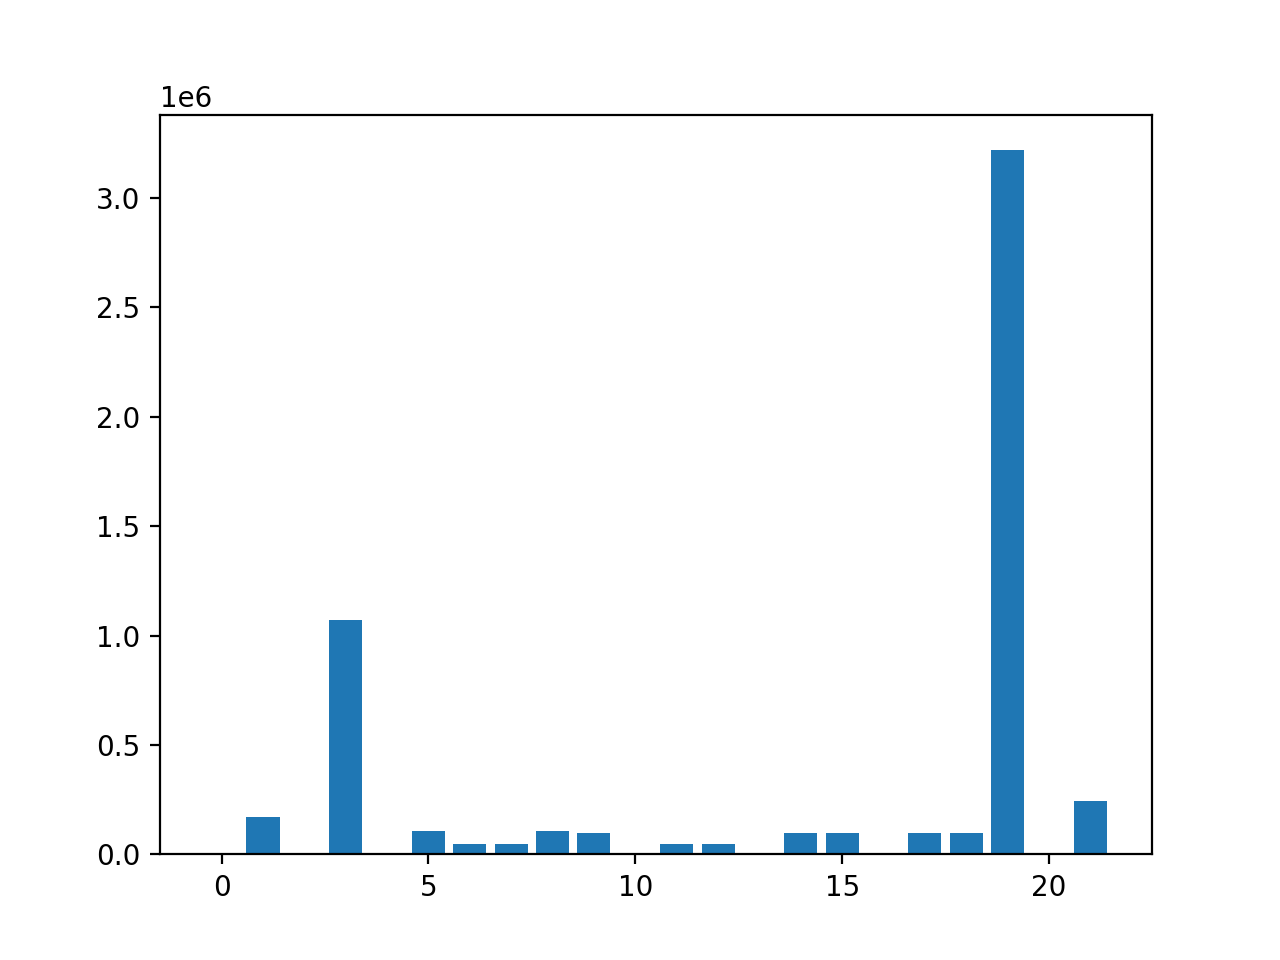

<BarContainer object of 22 artists>

In [9]:
# Generator outputs
bar(range(env.n_gen), env.chronics_handler.data.prod_p.sum(0))

<IPython.core.display.Javascript object>


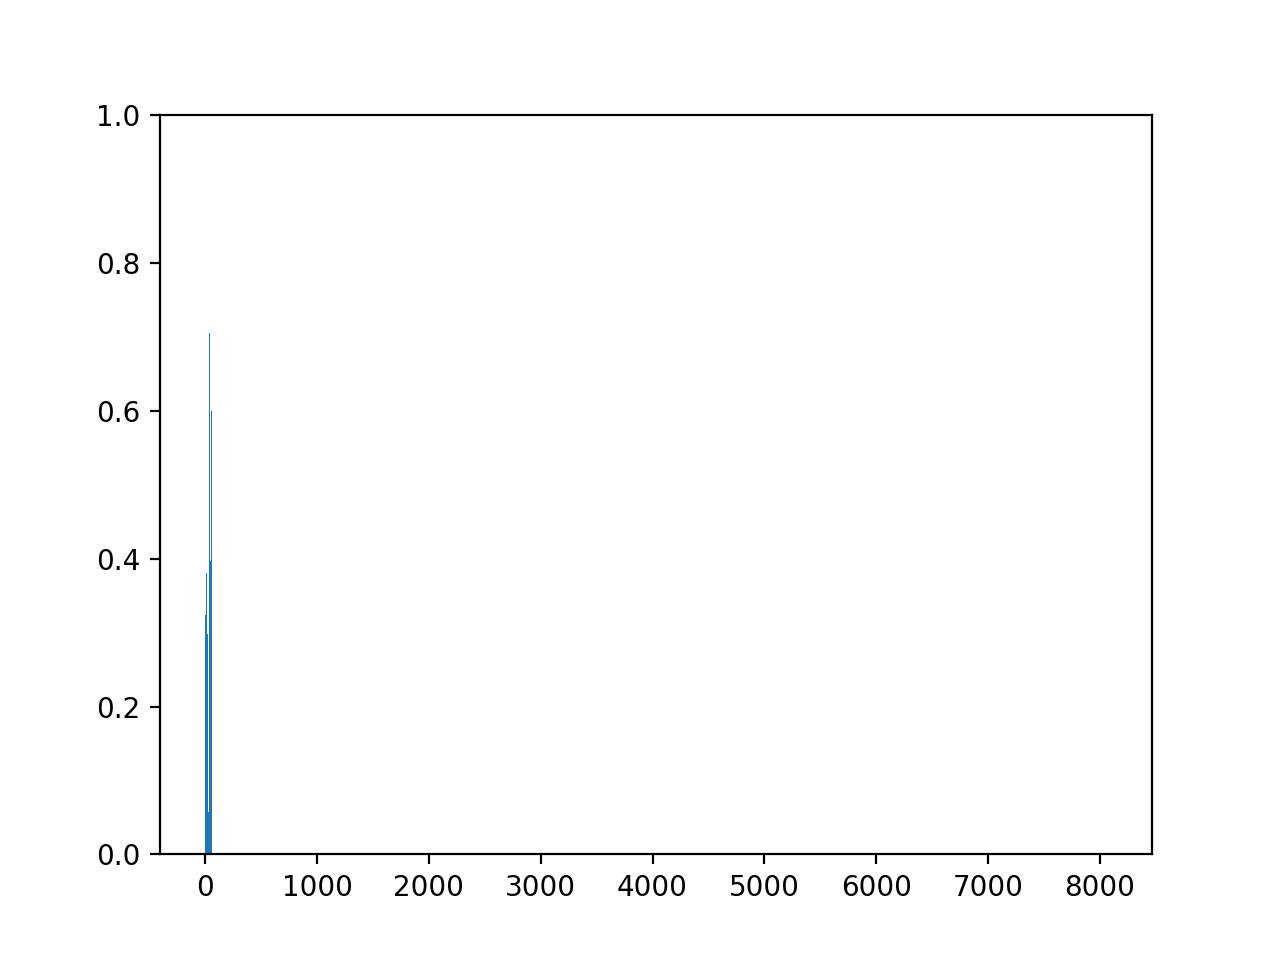

In [86]:
# Production vs load
plot(env.chronics_handler.data.prod_p.sum(1))
plot(env.chronics_handler.data.load_p.sum(1))

<IPython.core.display.Javascript object>


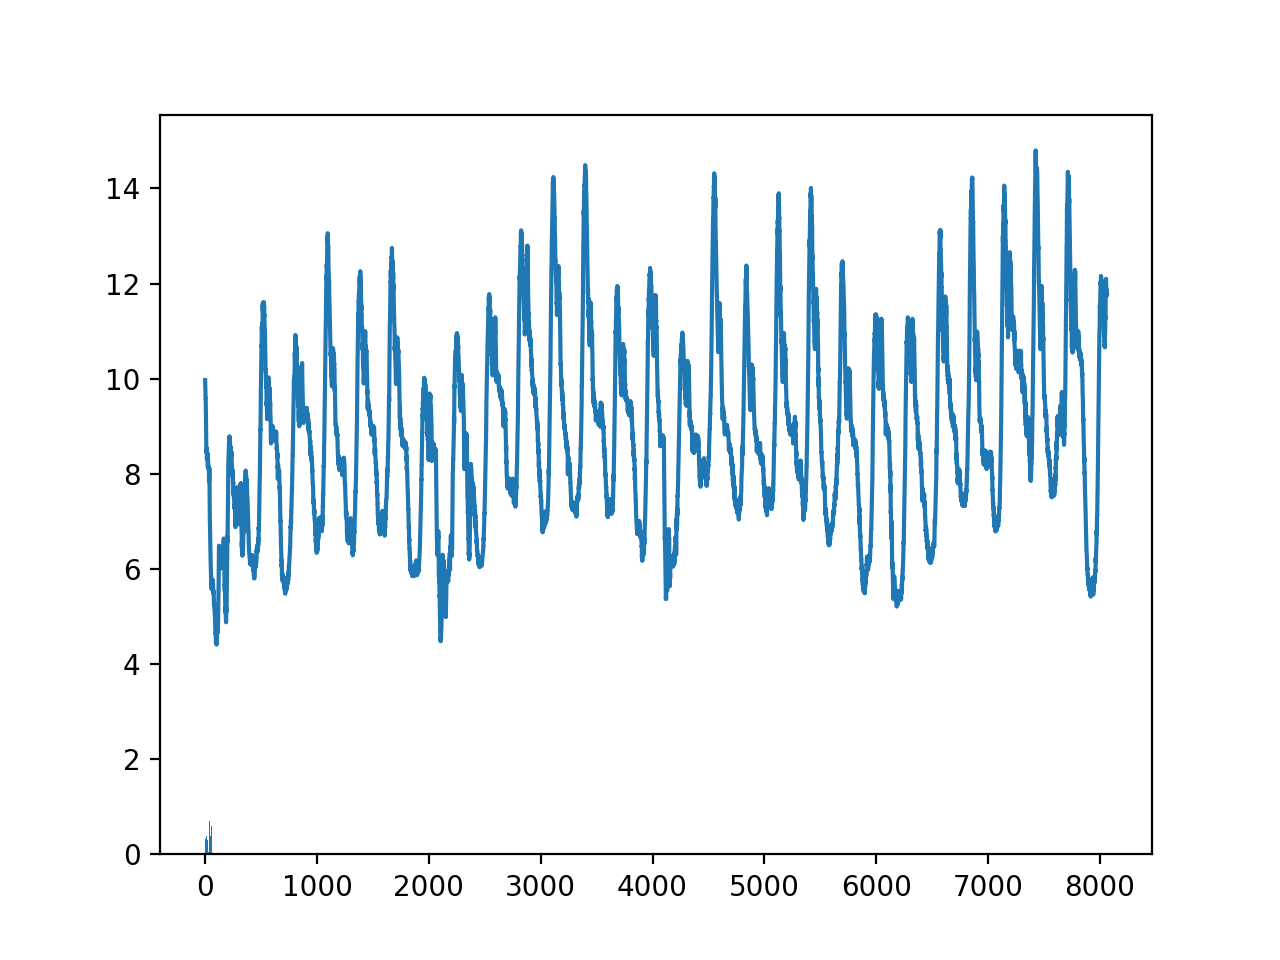

In [23]:
plot(env.chronics_handler.data.prod_p.sum(1) - env.chronics_handler.data.load_p.sum(1))

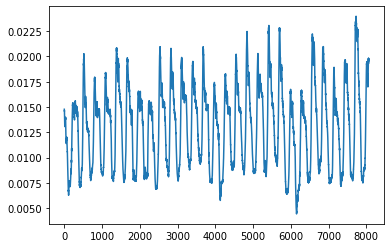

In [19]:
plot((env.chronics_handler.data.prod_p.sum(1) - env.chronics_handler.data.load_p.sum(1)) / env.chronics_handler.data.load_p.sum(1))

In [11]:
# Shorthand
data = env.chronics_handler.data

In [12]:
obs = env.get_obs()

<IPython.core.display.Javascript object>


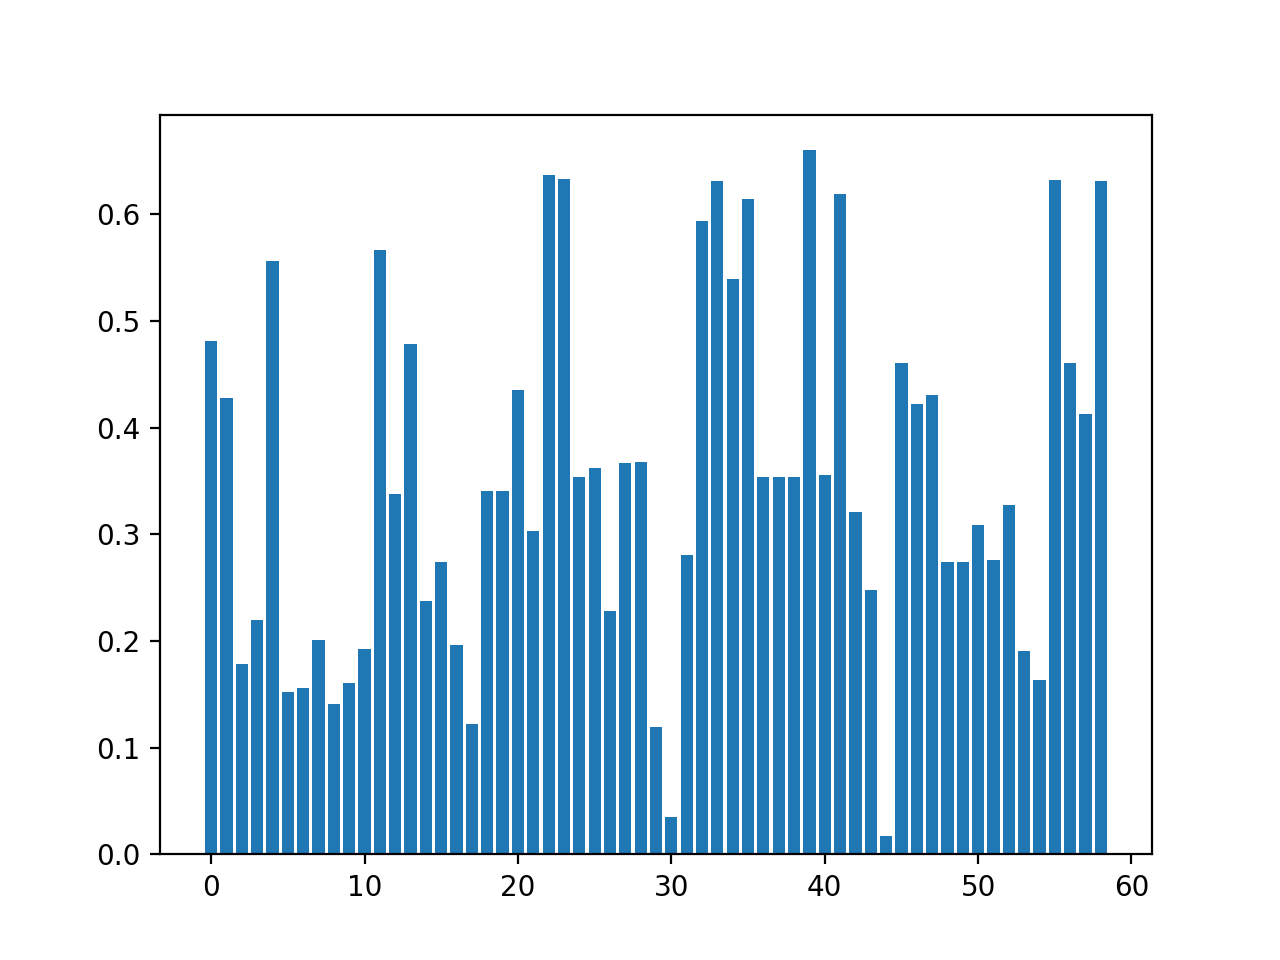

<BarContainer object of 59 artists>

In [13]:
bar(range(env.n_line), obs.rho)

In [85]:
# At a high load point
env.set_id(0)
env.reset()
env.fast_forward_chronics(3012)
obs2 = env.get_obs()
bar(range(env.n_line), obs2.rho)
ylim(0, 1)
print(median(obs2.rho))

<IPython.core.display.Javascript object>

0.28290233


<IPython.core.display.Javascript object>


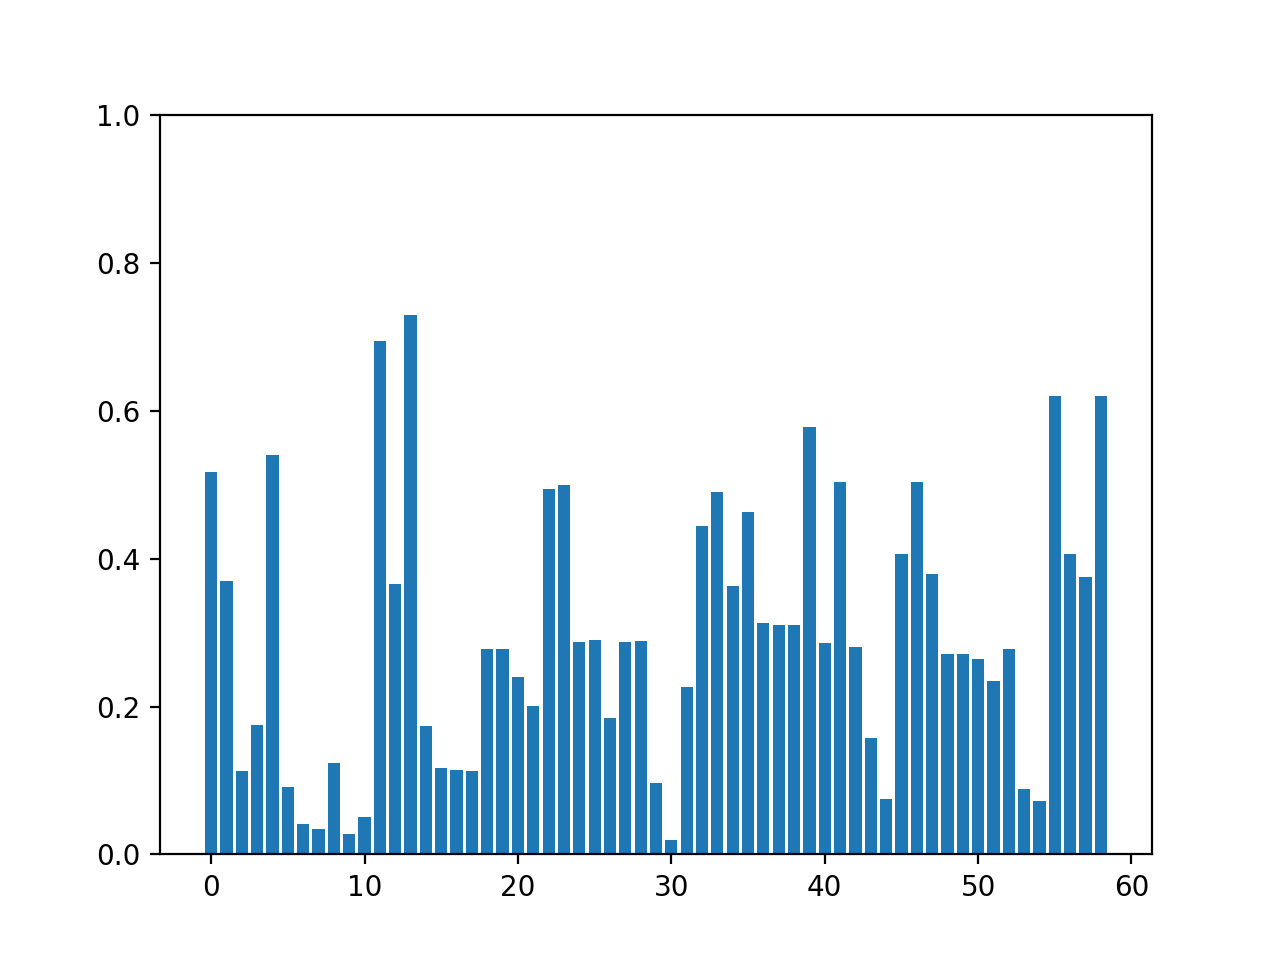

0.2811047


In [82]:
# At a low load point
env.set_id(0)
env.reset()
env.fast_forward_chronics(2362)
obs3 = env.get_obs()
bar(range(env.n_line), obs3.rho)
ylim(0, 1)
print(median(obs3.rho))

In [132]:
# Large (prod-load) at 7423
# Small (prod-load) at 7916
env.set_id(0)
env.seed(253)
env.reset()
env.fast_forward_chronics(7423)
obs = env.get_obs()
# bar(range(env.n_line), obs.rho)
# ylim(0, 1)
# print(median(obs.rho))

In [120]:
obs.rho.argmax()

41

In [133]:
env.step(env.action_space({
    'change_line_status': [41],
}))

(<grid2op.Space.GridObjects.CompleteObservation_l2rpn_neurips_2020_track1_small at 0x7fa08607e780>,
 875.32263,
 False,
 {'disc_lines': array([False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False]),
  'is_illegal': False,
  'is_ambiguous': False,
  'is_dispatching_illegal': False,
  'is_illegal_reco': False,
  'opponent_attack_line': None,
  'opponent_attack_sub': None,
  'opponent_attack_duration': 0,
  'exception': [],
  'rewards': {}})

In [134]:
obss2 = []
infos = []
null_ac = env.action_space({})
done = False
while not done:
    next_obs, rew, done, info = env.step(null_ac)
    obss2.append(next_obs)
    infos.append(info)
    if len(info['exception']) > 0:
        print(info)

In [114]:
[where(info['opponent_attack_line'])[0] for info in infos if info['opponent_attack_line'] is not None]

[array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([0]),
 array([27]),
 array([27]),
 array([27]),
 array([27]),
 array([27]),
 array([27]),
 array([27]),
 array([27]),
 array([27]),
 array([27]),
 array([27]),
 array([27]),
 array([27]),
 array([27]),
 array([27]),
 array([27]),
 array([27]),
 array([27]),
 array([27]),
 array([27]),
 array([27]),
 array([27]),
 array([27]),
 array([27]),
 array([27]),
 array([27]),
 array([27])

<IPython.core.display.Javascript object>


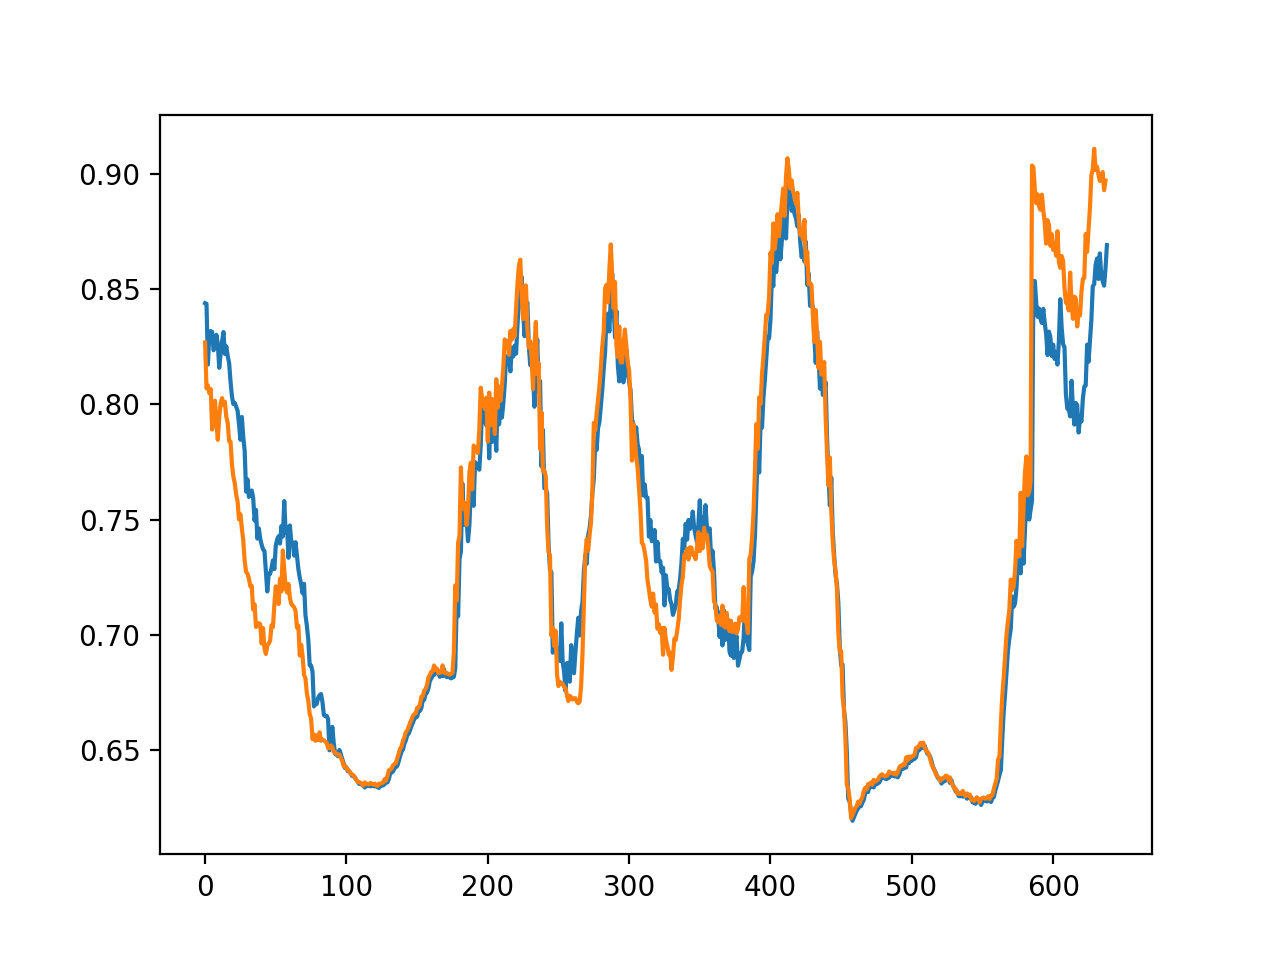

In [135]:
plt.figure()
plot([ob.rho.max() for ob in obss])
plot([ob.rho.max() for ob in obss2])

<IPython.core.display.Javascript object>


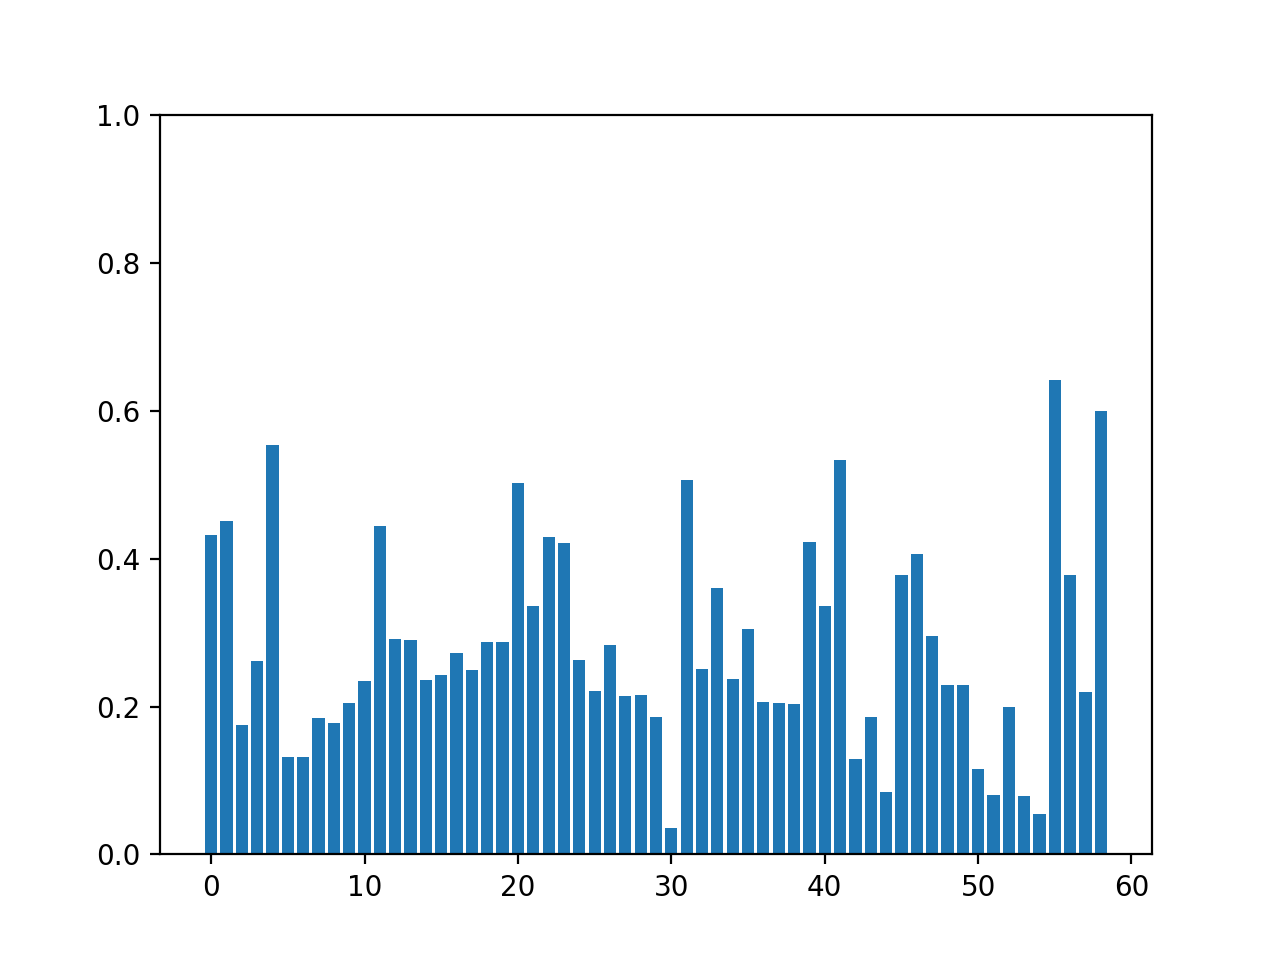

0.24969956


In [84]:
# Low (prod - load) point
env.set_id(0)
env.reset()
env.fast_forward_chronics(7916)
obs = env.get_obs()
bar(range(env.n_line), obs.rho)
ylim(0, 1)
print(median(obs.rho))

In [32]:
obs.rho[39]

0.0

In [34]:
obs.line_status[39]

False

In [42]:
obs.state_of(line_id=39)

{'origin': {'p': 0.0, 'q': 0.0, 'v': 0.0, 'a': 0.0, 'bus': -1, 'sub_id': 22},
 'extremity': {'p': 0.0,
  'q': 0.0,
  'v': 0.0,
  'a': 0.0,
  'bus': -1,
  'sub_id': 26},
 'maintenance': {'next': -1, 'duration_next': 0},
 'cooldown_time': 47}

In [47]:
data.maintenance_time[:, 39]

array([-1, -1, -1, ..., -1, -1, -1], dtype=int32)

<IPython.core.display.Javascript object>


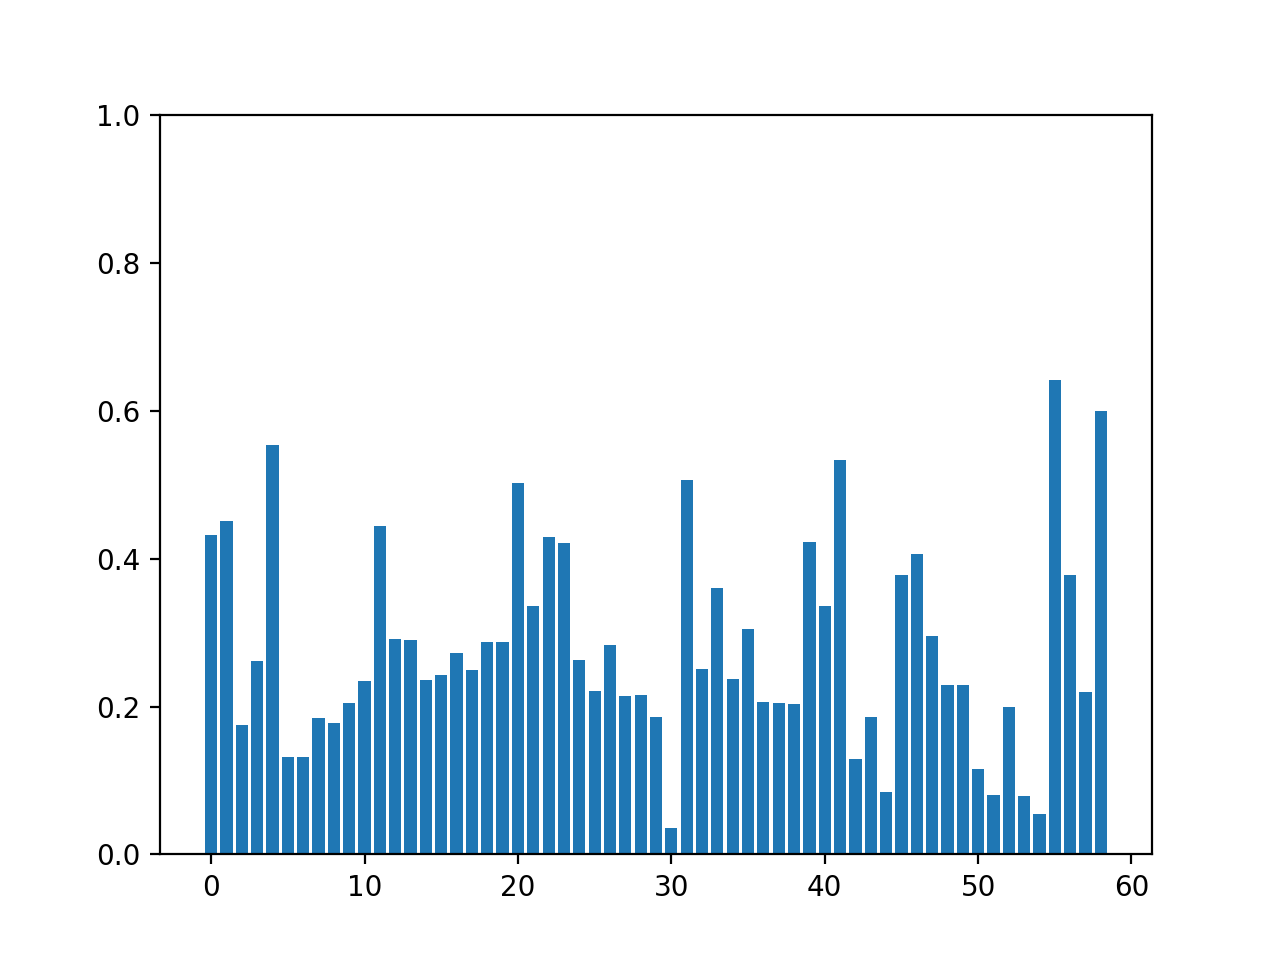

(0.0, 1.0)

In [79]:
env.set_id(0)
env.reset()
# env.fast_forward_chronics(7860)
env.fast_forward_chronics(7916)
obs = env.get_obs()
bar(range(env.n_line), obs.rho)
ylim(0, 1)

In [51]:
obs.state_of(line_id=39)

{'origin': {'p': -10.520088,
  'q': -0.8130336,
  'v': 147.8,
  'a': 41.2171,
  'bus': 1,
  'sub_id': 22},
 'extremity': {'p': 10.568241,
  'q': -5.4440618,
  'v': 147.8,
  'a': 46.438183,
  'bus': 1,
  'sub_id': 26},
 'maintenance': {'next': -1, 'duration_next': 0},
 'cooldown_time': 0}

In [52]:
7916 - (96-47)

7867

In [77]:
env.fast_forward_chronics(5)
obs2 = env.get_obs()
obs2.state_of(line_id=39)

{'origin': {'p': -9.127501,
  'q': -1.1473149,
  'v': 147.8,
  'a': 35.93527,
  'bus': 1,
  'sub_id': 22},
 'extremity': {'p': 9.163726,
  'q': -5.1640954,
  'v': 147.8,
  'a': 41.088894,
  'bus': 1,
  'sub_id': 26},
 'maintenance': {'next': -1, 'duration_next': 0},
 'cooldown_time': 0}

In [78]:
env.nb_time_step, obs2.rho[39]

(7920, 0.4168825)

In [136]:
obss = []
infos = []
env.set_id(0)
env.seed(253)
obs = env.reset()
null_ac = env.action_space({})
done = False
while not done:
    next_obs, rew, done, info = env.step(null_ac)
    obss.append(next_obs)
    infos.append(info)
    if len(info['exception']) > 0:
        print(info)

{'disc_lines': array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True,  True, False,  True, False,
       False,  True, False, False,  True,  True,  True,  True,  True,
       False, False, False,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False]), 'is_illegal': False, 'is_ambiguous': False, 'is_dispatching_illegal': False, 'is_illegal_reco': False, 'opponent_attack_line': array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True, False, False, False, False, Fa

<IPython.core.display.Javascript object>


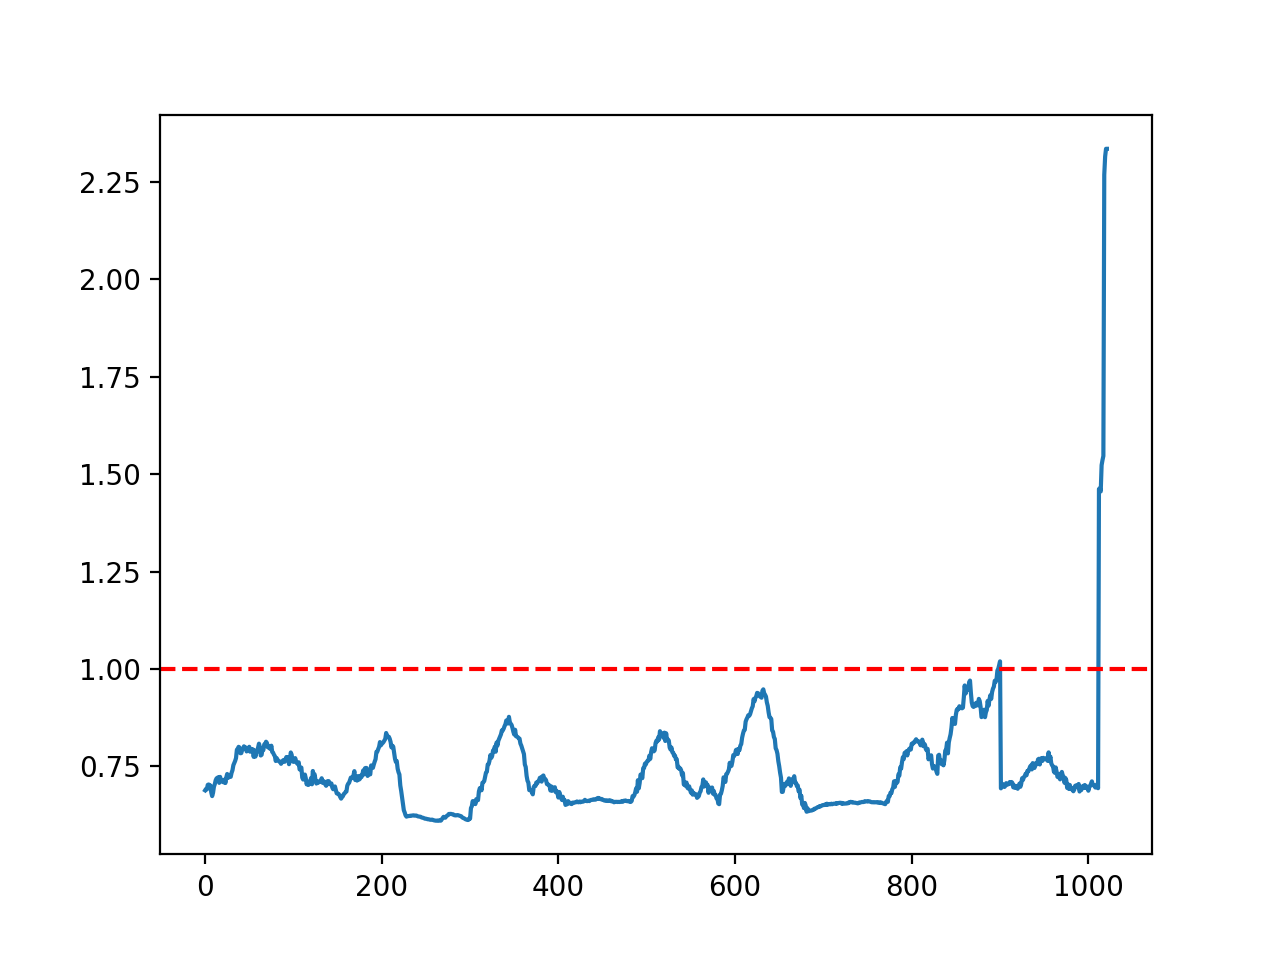

In [148]:
plt.figure()
plot([ob.rho.max() for ob in obss])
axhline(1, ls='--', c='r')

In [152]:
rhos = vstack([ob.rho for ob in obss])

<IPython.core.display.Javascript object>


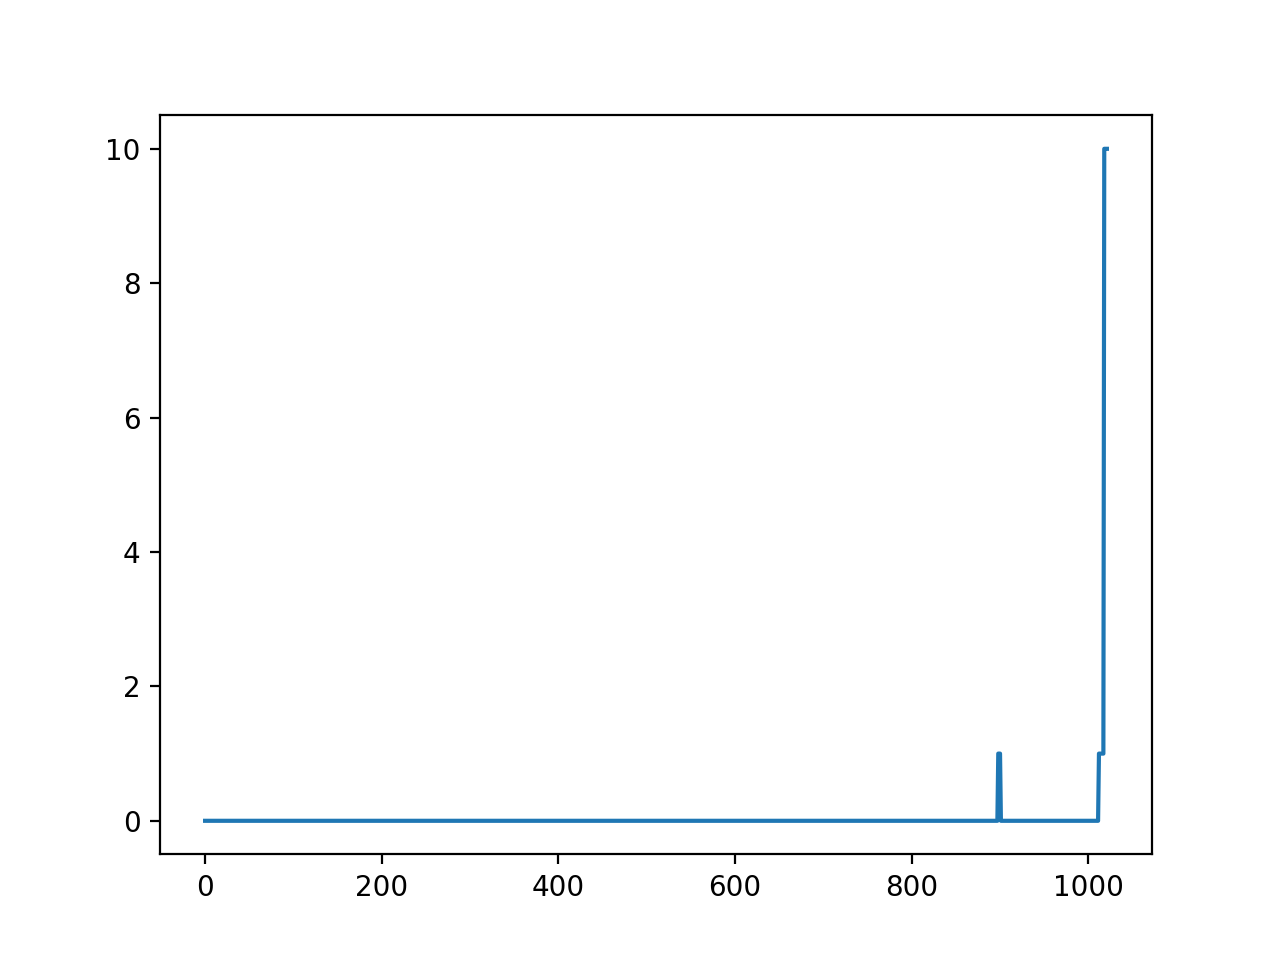

In [165]:
plt.figure()
plot((rhos > 1).sum(1))

In [156]:
infos[1012]

{'disc_lines': array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False]),
 'is_illegal': False,
 'is_ambiguous': False,
 'is_dispatching_illegal': False,
 'is_illegal_reco': False,
 'opponent_attack_line': array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
         True, False, False, 

In [157]:
where(infos[1012]['opponent_attack_line'])[0]

array([45])

<IPython.core.display.Javascript object>


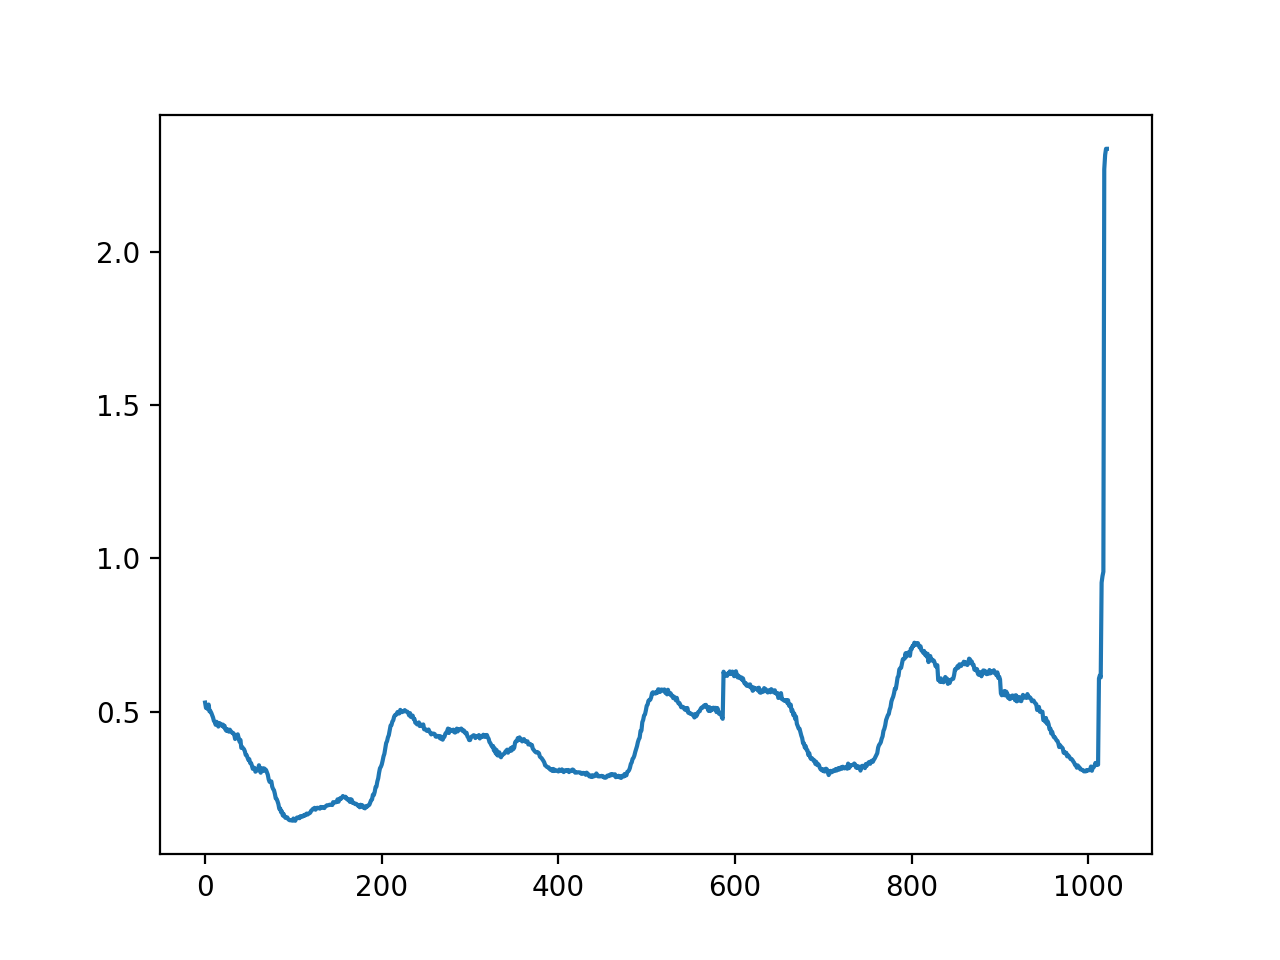

In [153]:
plt.figure()
plot(rhos[:, 34])

In [166]:
env.reset()

In [179]:
print(env.action_space({
    'change_bus': {
        'lines_or_id': [0],
        'lines_ex_id': [0],
    }
}))

This action will:
	 - NOT change anything to the injections
	 - NOT perform any redispatching action
	 - NOT force any line status
	 - NOT switch any line status
	 - Change the bus of the following element:
	 	 - switch bus of line (origin) 0 [on substation 2]
	 	 - switch bus of line (extremity) 0 [on substation 3]
	 - NOT force any particular bus configuration


In [186]:
where(rhos > 1)

(array([ 898,  899,  900, 1012, 1013, 1014, 1015, 1016, 1017, 1018, 1018,
        1018, 1018, 1018, 1018, 1018, 1018, 1018, 1018, 1019, 1019, 1019,
        1019, 1019, 1019, 1019, 1019, 1019, 1019, 1020, 1020, 1020, 1020,
        1020, 1020, 1020, 1020, 1020, 1020, 1021, 1021, 1021, 1021, 1021,
        1021, 1021, 1021, 1021, 1021]),
 array([13, 13, 13, 41, 41, 41, 40, 40, 40, 22, 23, 25, 28, 31, 32, 33, 34,
        35, 39, 22, 23, 25, 28, 31, 32, 33, 34, 35, 39, 22, 23, 25, 28, 31,
        32, 33, 34, 35, 39, 22, 23, 25, 28, 31, 32, 33, 34, 35, 39]))

In [194]:
from grid2op.PlotGrid import PlotMatplot
plot_helper = PlotMatplot(env.observation_space, line_id=True)

In [246]:
obss[1011].state_of(load_id=1)

{'p': -4.38, 'q': -2.17, 'v': 147.54622, 'bus': 1, 'sub_id': 0}

In [247]:
list(zip(obss[1011].name_load, obss[1011].load_p<0))[27]

('load_58_50', False)

In [239]:
env.chronics_handler.get_name()

'Scenario_april_001'

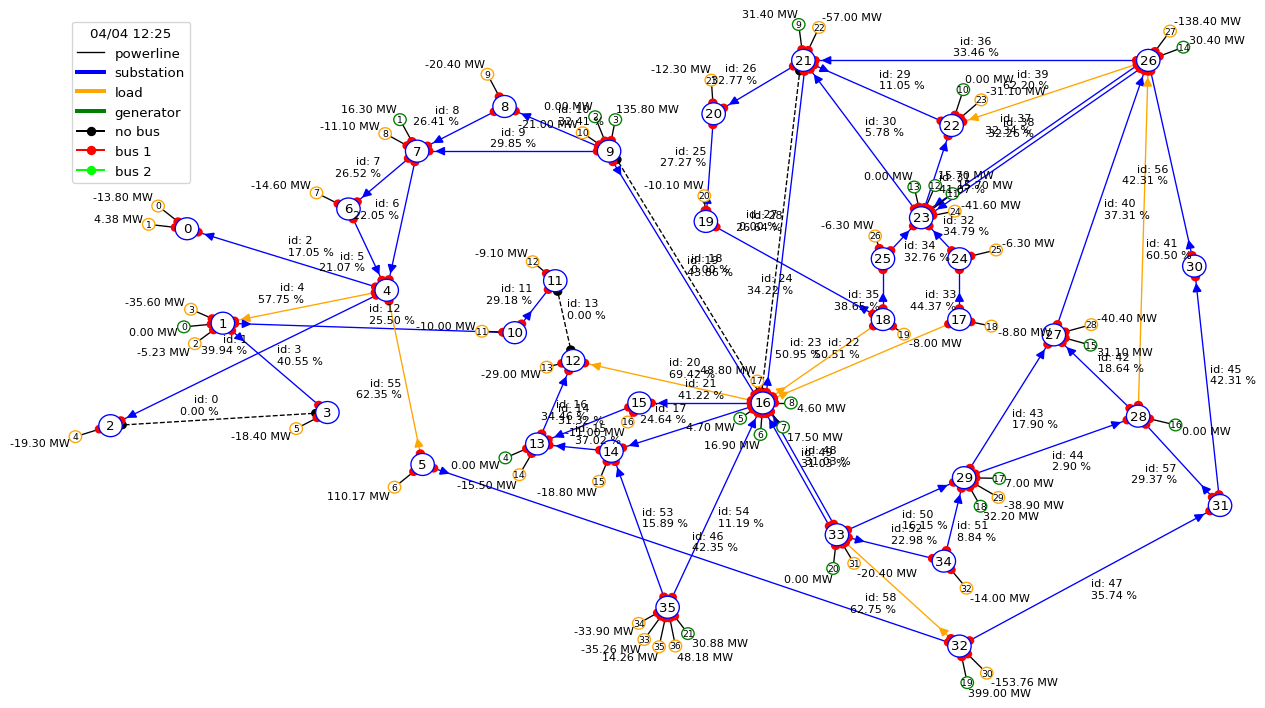

In [234]:
_ = plot_helper.plot_obs(obss[1011])

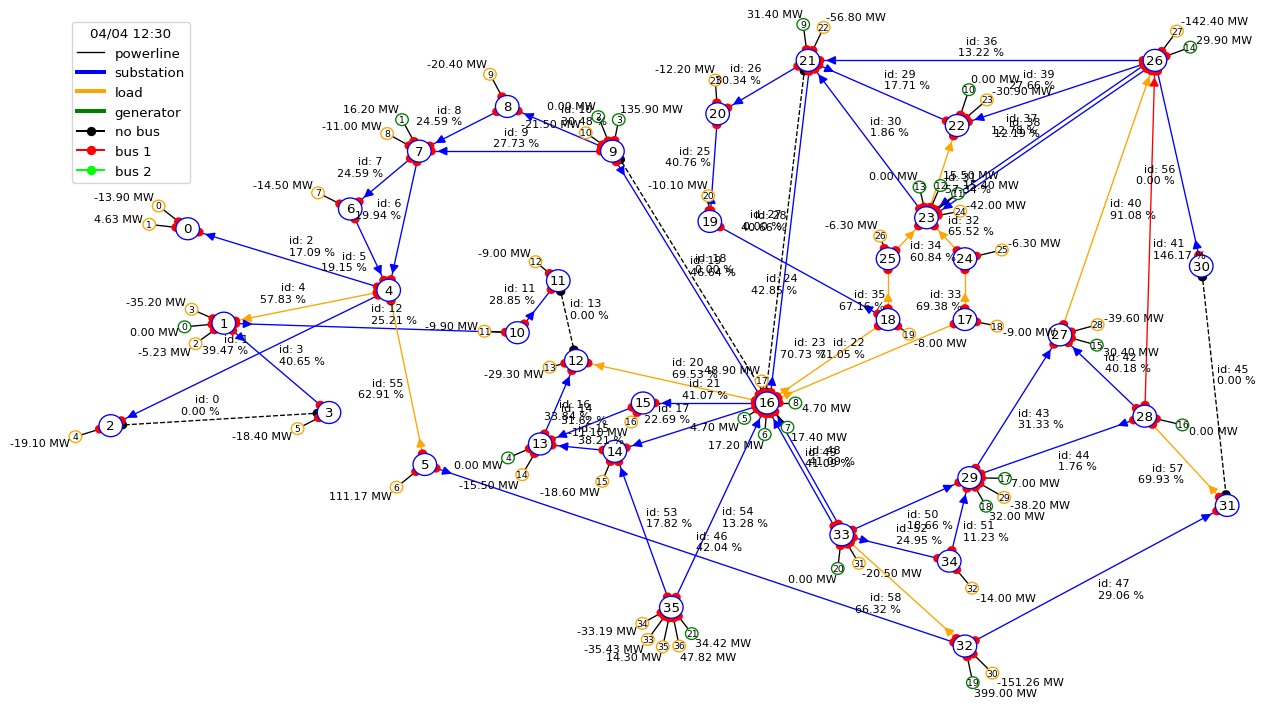

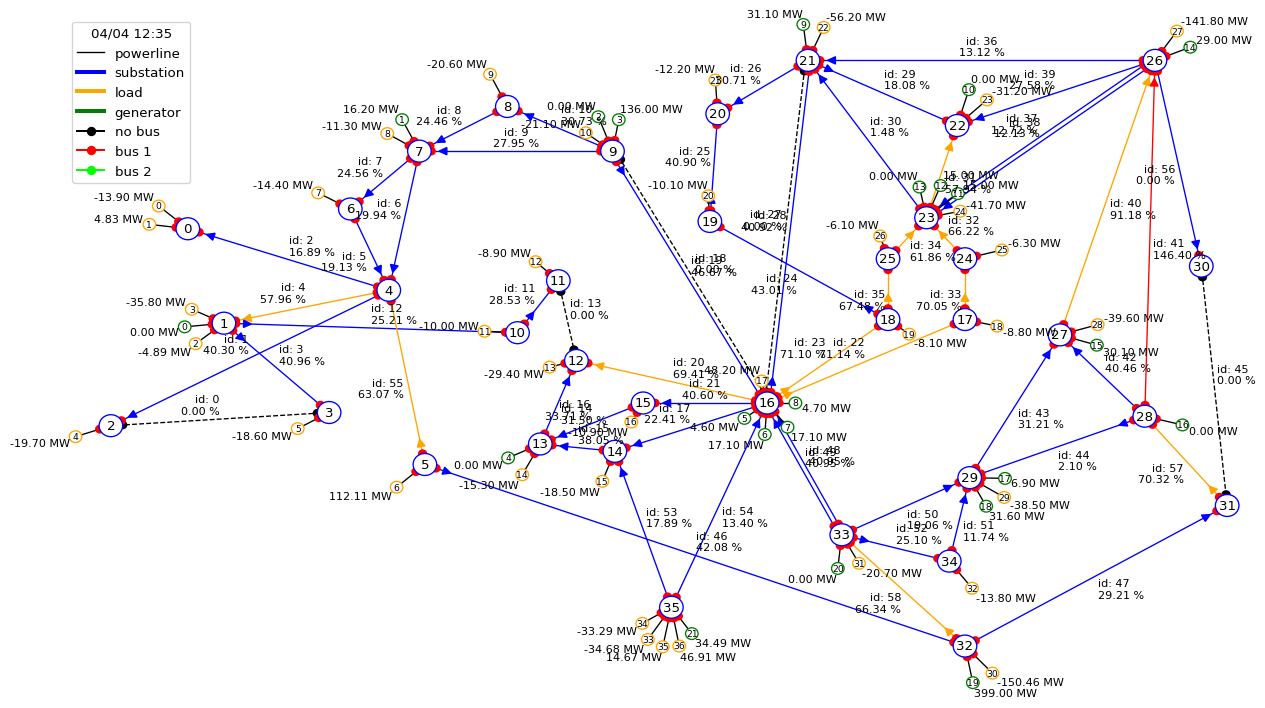

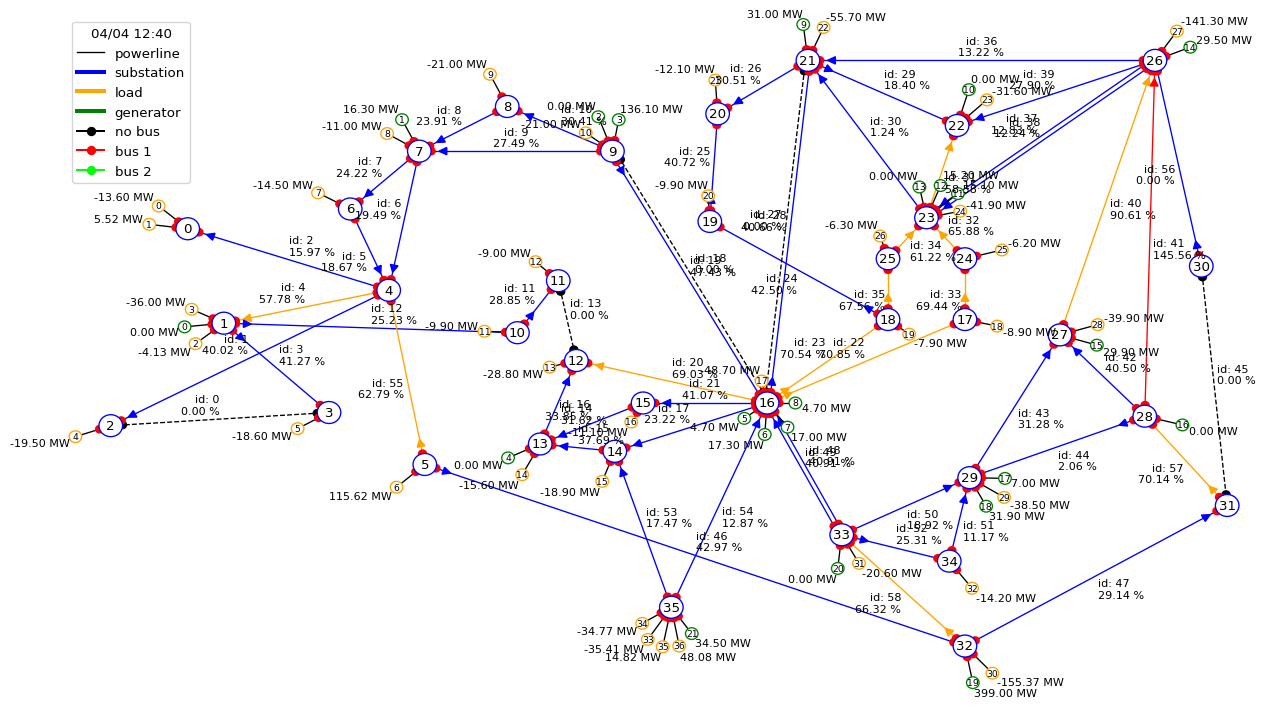

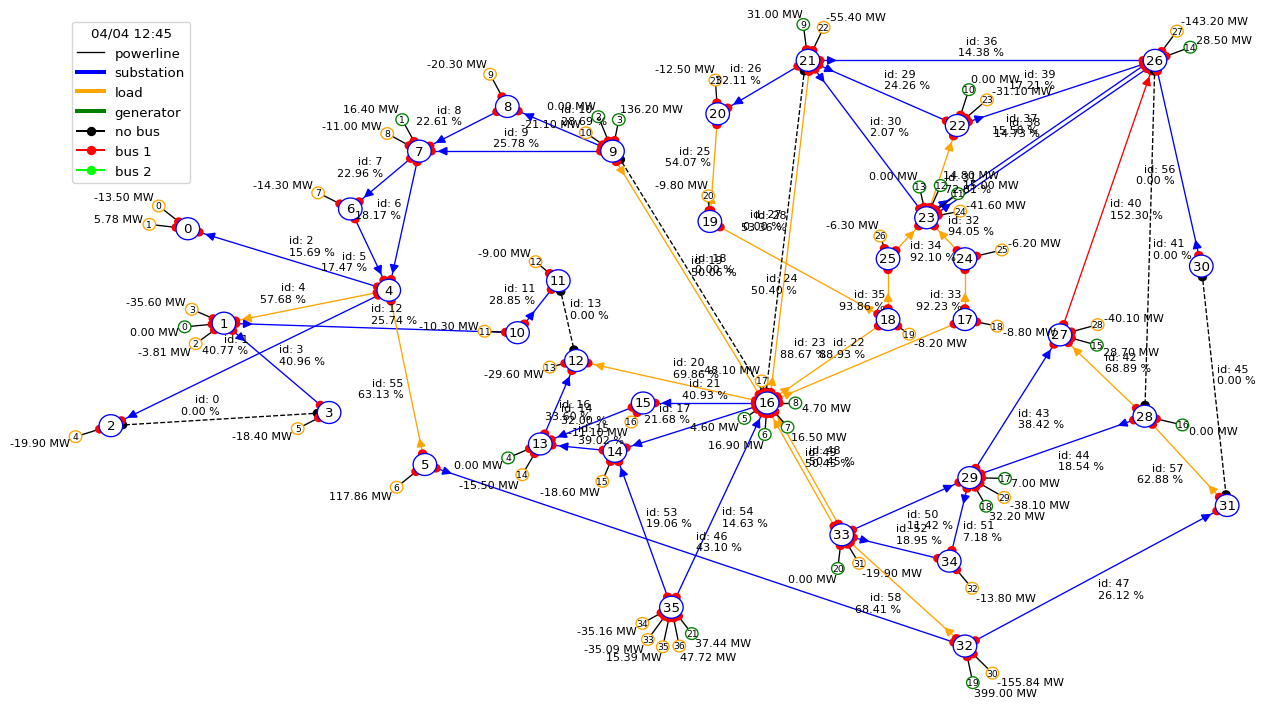

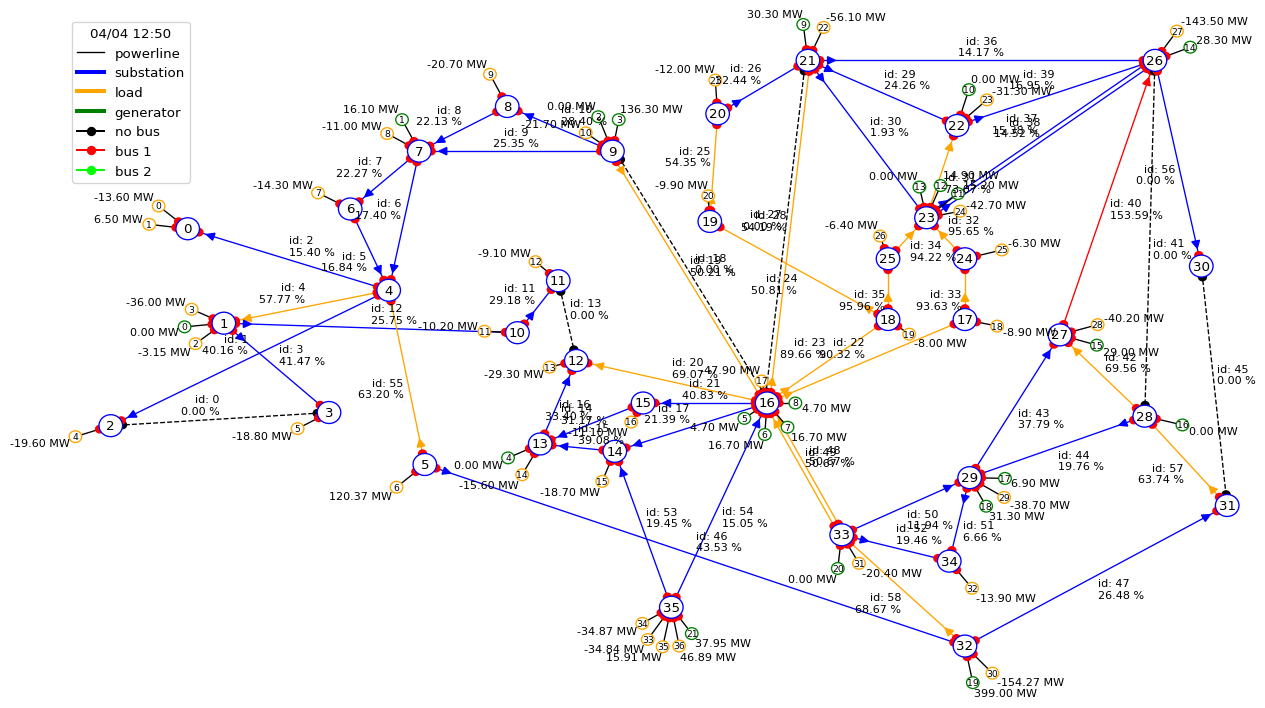

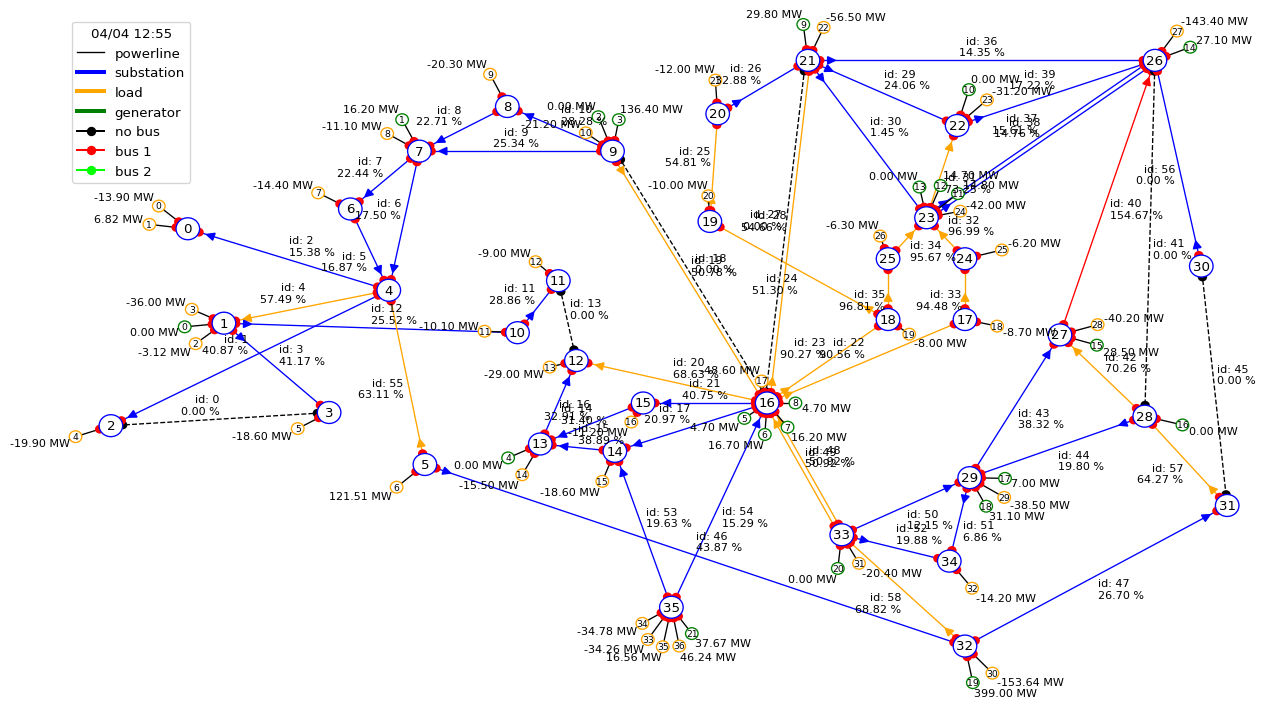

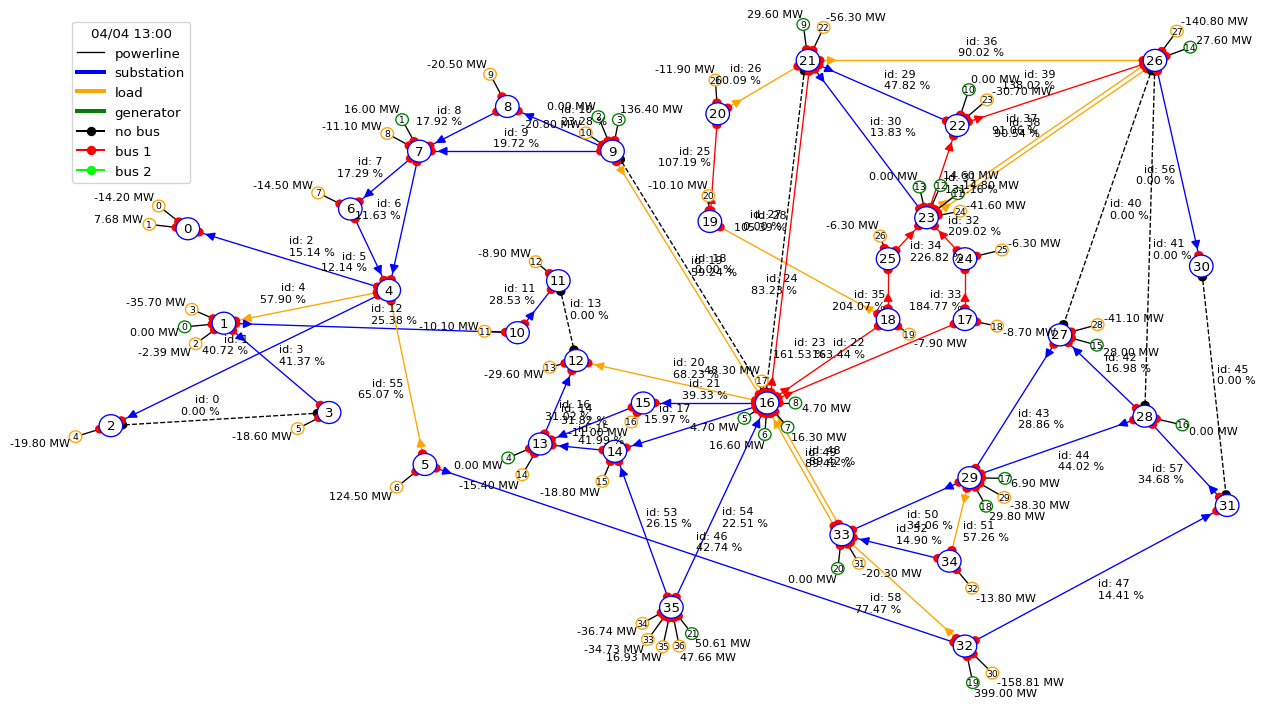

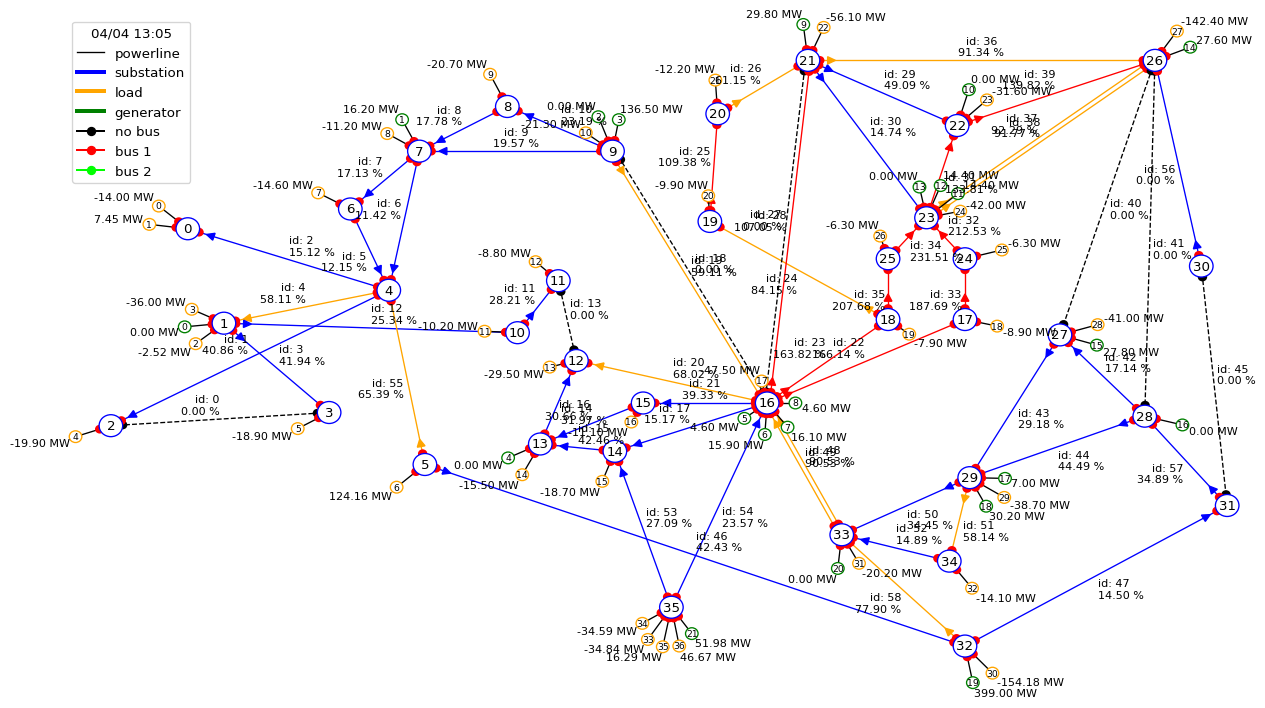

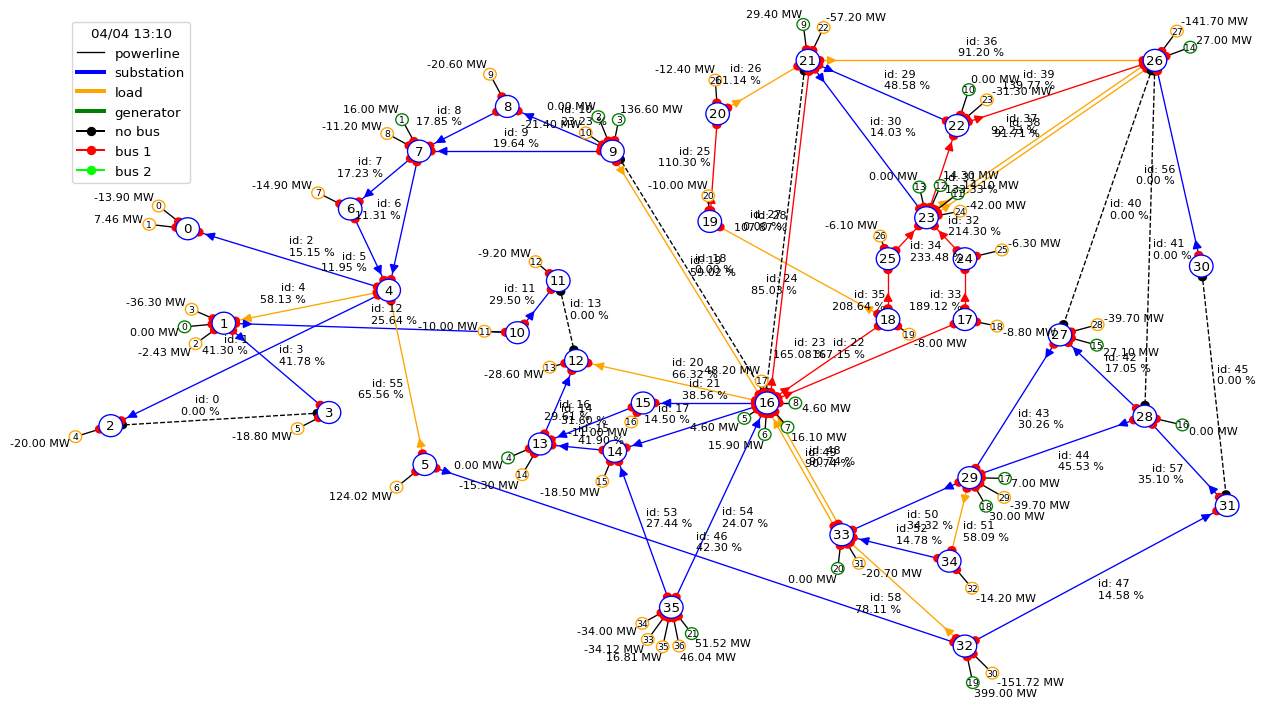

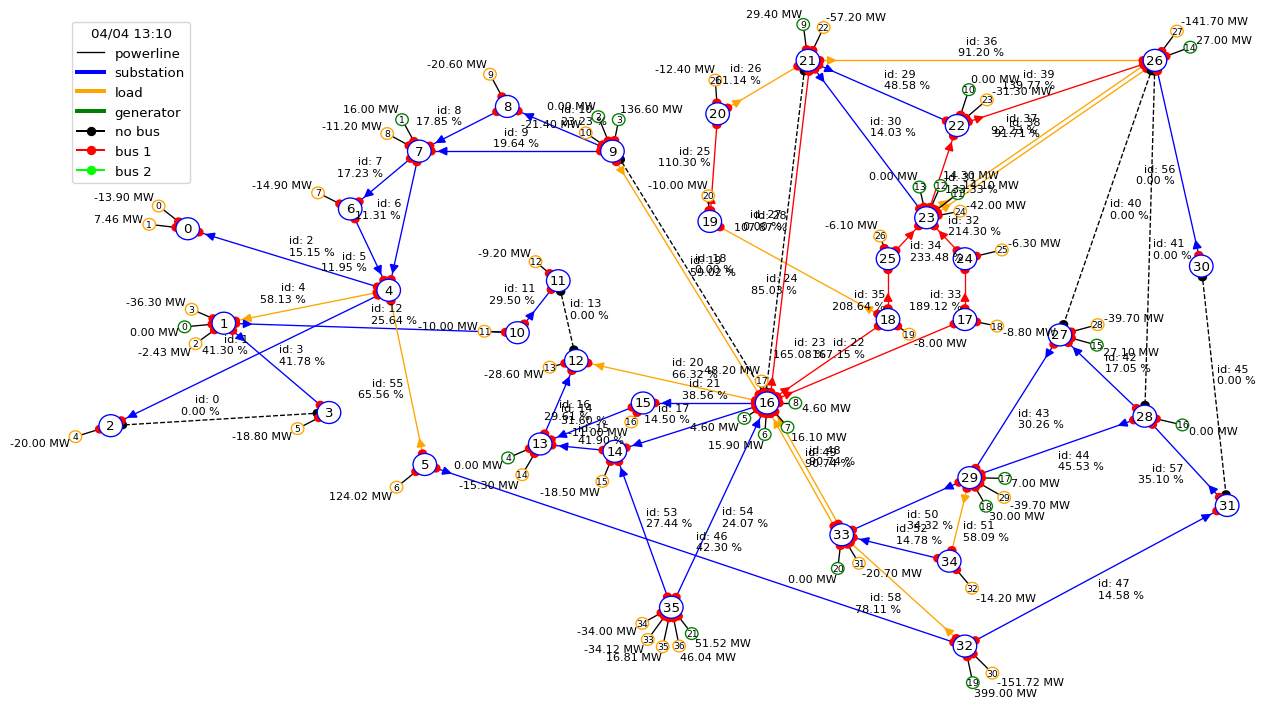

In [204]:
for ob in obss[1012:]:
    _ = plot_helper.plot_obs(ob)

In [236]:
obss[1012].state_of(line_id=41)

{'origin': {'p': -66.31502,
  'q': 15.503767,
  'v': 147.8,
  'a': 266.03122,
  'bus': 1,
  'sub_id': 26},
 'extremity': {'p': 67.6624,
  'q': -13.792628,
  'v': 147.8,
  'a': 269.7447,
  'bus': 1,
  'sub_id': 28},
 'maintenance': {'next': -1, 'duration_next': 0},
 'cooldown_time': 0}

In [221]:
r = eye(36)
for _ in range(36):
    r = r @ obs.bus_connectivity_matrix()

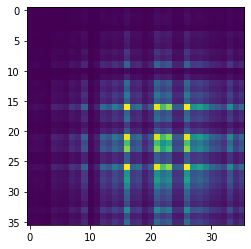

In [233]:
imshow(r, interpolation='none')

In [218]:
obs.bus_connectivity_matrix().shape

(36, 36)

In [210]:
env.backend.nb_bus_total

72

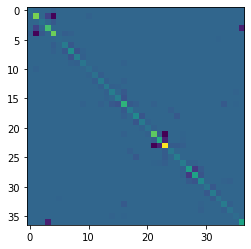

In [230]:
imshow(env.backend._grid.get_Ybus().todense().real, interpolation='none')

In [231]:
env.backend._grid.get_Ybus().todense().real

matrix([[ 189.61676852,    0.        ,    0.        , ...,    0.        ,
            0.        ,    0.        ],
        [   0.        , 3931.85867646,    0.        , ...,    0.        ,
            0.        ,    0.        ],
        [   0.        ,    0.        ,  424.53176076, ...,    0.        ,
            0.        ,    0.        ],
        ...,
        [   0.        ,    0.        ,    0.        , ...,  387.06325145,
            0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        , ...,    0.        ,
          186.01562337,    0.        ],
        [   0.        ,    0.        ,    0.        , ...,    0.        ,
            0.        , 2053.96047593]])

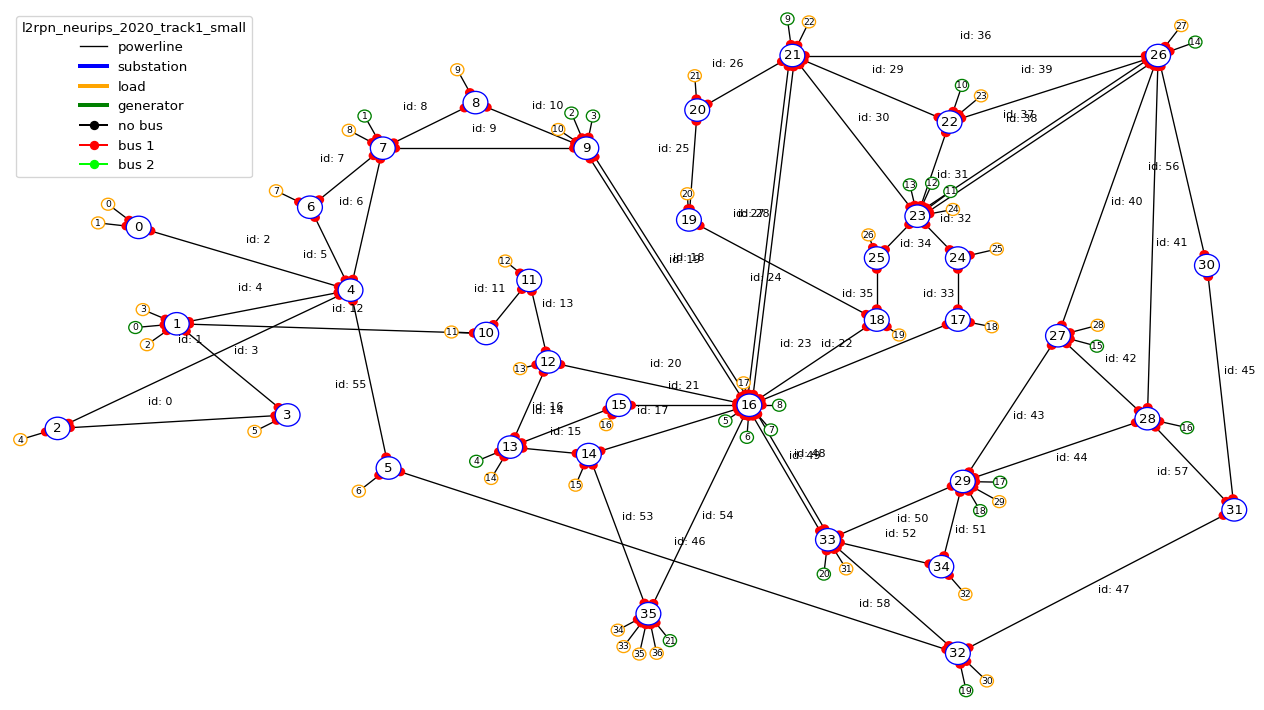

In [263]:
_ = plot_helper.plot_layout()

In [265]:
obs.state_of(substation_id=0)

{'topo_vect': array([1, 1, 1], dtype=int32), 'nb_bus': 1, 'cooldown_time': 0}

In [266]:
env.backend.name_sub

array(['sub_0', 'sub_1', 'sub_2', 'sub_3', 'sub_4', 'sub_5', 'sub_6',
       'sub_7', 'sub_8', 'sub_9', 'sub_10', 'sub_11', 'sub_12', 'sub_13',
       'sub_14', 'sub_15', 'sub_16', 'sub_17', 'sub_18', 'sub_19',
       'sub_20', 'sub_21', 'sub_22', 'sub_23', 'sub_24', 'sub_25',
       'sub_26', 'sub_27', 'sub_28', 'sub_29', 'sub_30', 'sub_31',
       'sub_32', 'sub_33', 'sub_34', 'sub_35'], dtype='<U6')

In [276]:
env.backend.get_obj_connect_to(substation_id=0)

{'loads_id': array([0, 1]),
 'generators_id': array([], dtype=int64),
 'lines_or_id': array([2]),
 'lines_ex_id': array([], dtype=int64),
 'nb_elements': 3}

In [271]:
env.backend.init_pp_backend._grid.bus

,in_service,max_vm_pu,min_vm_pu,name,type,vn_kv,zone,PF,old_name
0,True,1.06,0.94,sub_32,b,138.0,R2,0.013266,32
1,True,1.06,0.94,sub_33,b,138.0,R2,0.034024,33
2,True,1.06,0.94,sub_34,b,138.0,R2,0.019030,34
3,True,1.06,0.94,sub_35,b,138.0,R2,0.017878,35
4,True,1.06,0.94,sub_36,b,138.0,R2,0.000000,36
...,...,...,...,...,...,...,...,...,...
67,False,1.06,0.94,sub_63,b,345.0,R2,0.000000,63
68,False,1.06,0.94,sub_64,b,345.0,R2,0.000000,64
69,False,1.06,0.94,sub_65,b,138.0,R2,0.021187,65
70,False,1.06,0.94,sub_66,b,138.0,R2,0.015211,66


In [262]:
env.backend.nb_obj_per_bus

array([2, 4, 2, 2, 3, 2, 3, 4, 3, 4, 3, 4, 4, 5, 3, 4, 4, 3, 3, 3, 3, 4,
       4, 4, 2, 2, 4, 4, 3, 4, 1, 2, 4, 4, 2, 3, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0])

In [277]:
obs.get_obj_substations(substation_id=0)

array([[ 0, -1, -1,  2, -1],
       [ 0,  0, -1, -1, -1],
       [ 0,  1, -1, -1, -1]], dtype=int32)

In [278]:
obs.state_of(gen_id=0)

{'p': 0.0,
 'q': -69.72284,
 'v': 147.8,
 'bus': 1,
 'sub_id': 1,
 'target_dispatch': 0.0,
 'actual_dispatch': 0.0}

In [304]:
def bus_id(sub_id, bus_num):
    return sub_id * 2 + bus_num - 1

In [358]:
def get_excess(obs):
    n_bus = obs.n_sub * 2
    excess = zeros(n_bus)
    # Generators
    for gen_id in range(obs.n_gen):
        st = obs.state_of(gen_id=gen_id)
        excess[bus_id(st['sub_id'], st['bus'])] += st['p']
    # Loads
    for load_id in range(obs.n_load):
        st = obs.state_of(load_id=load_id)
        excess[bus_id(st['sub_id'], st['bus'])] -= st['p']
    return excess

In [360]:
exc = get_excess(obs)
exc

array([  -2.03999996,    0.        ,  -23.27000046,    0.        ,
        -13.5       ,    0.        ,  -14.19999981,    0.        ,
          0.        ,    0.        ,  140.27000427,    0.        ,
        -12.5       ,    0.        ,   -5.10000038,    0.        ,
        -17.20000076,    0.        ,  117.09999466,    0.        ,
         -7.80000019,    0.        ,   -7.        ,    0.        ,
        -23.89999962,    0.        ,  -12.5       ,    0.        ,
        -14.89999962,    0.        ,   -9.30000019,    0.        ,
        -35.20000148,    0.        ,   -7.9000001 ,    0.        ,
         -7.69999981,    0.        ,   -7.5999999 ,    0.        ,
         -9.5       ,    0.        ,  -54.90000153,    0.        ,
        -28.        ,    0.        ,  -41.70000076,    0.        ,
         -5.5999999 ,    0.        ,   -5.80000019,    0.        ,
       -117.5       ,    0.        ,  -35.20000076,    0.        ,
          0.        ,    0.        ,  -26.49999809,    0.     

<BarContainer object of 72 artists>

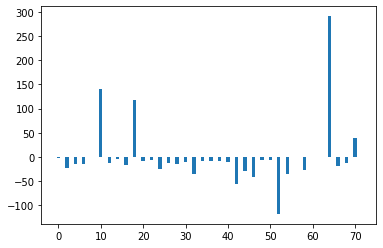

In [361]:
bar(range(72), exc)

In [362]:
exc.argmax(), exc.argmin()

(64, 52)

In [363]:
exc[52]

-117.5

In [364]:
# The least to most imbalanced buses
abs(exc).argsort()

array([35, 31, 33, 37, 39, 41, 43, 45, 47, 49, 51, 29, 53, 56, 57, 59, 60,
       61, 62, 63, 65, 67, 69, 55, 27, 71,  1,  3, 23,  5,  7,  8, 21,  9,
       11, 13, 25, 19, 15, 17,  0, 14, 48, 50, 22, 38, 36, 20, 34, 30, 40,
       68, 12, 26,  4,  6, 28, 16, 66,  2, 24, 58, 44, 54, 32, 70, 46, 42,
       18, 52, 10, 64])

In [357]:
# The range of imbalance possible
env.gen_max_ramp_down

array([ 1.4,  0. ,  1.4, 10.4,  1.4,  0. ,  0. ,  0. ,  0. ,  0. ,  2.8,
        0. ,  0. ,  2.8,  0. ,  0. ,  4.3,  0. ,  0. ,  2.8,  8.5,  9.9],
      dtype=float32)

In [392]:
max(env.gen_cost_per_MW)

48.0

In [389]:
env.backend.init_pp_backend.gen_cost_per_MW

array([45.,  0., 46., 36., 48.,  0.,  0.,  0.,  0.,  0., 46.,  0.,  0.,
       44.,  0.,  0., 46.,  0.,  0., 35., 48., 40.], dtype=float32)

In [388]:
env.backend.init_pp_backend.gen_pmax, env.backend.init_pp_backend.gen_pmin

(array([ 50. ,  67.2,  50. , 250. ,  50. ,  33.6,  37.3,  37.3,  33.6,
         74.7, 100. ,  37.3,  37.3, 100. ,  74.7,  74.7, 150. ,  67.2,
         74.7, 400. , 300. , 350. ], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0.], dtype=float32))

In [300]:
# Current at origin / thermal_limit = relative flow
obs.rho

array([0.5285495 , 0.40312487, 0.12503462, 0.20233648, 0.54849577,
       0.09048162, 0.03810555, 0.08246578, 0.13386856, 0.14326276,
       0.17602502, 0.7095899 , 0.39255667, 0.6964621 , 0.22310428,
       0.24994962, 0.13797133, 0.08331564, 0.35338604, 0.35338604,
       0.34949926, 0.2651093 , 0.6335667 , 0.6260409 , 0.34813532,
       0.36040655, 0.22894613, 0.3619997 , 0.36323303, 0.11709379,
       0.03240786, 0.27658582, 0.58005077, 0.62301797, 0.529023  ,
       0.60822105, 0.3728063 , 0.3728375 , 0.37234542, 0.6924352 ,
       0.35134646, 0.61968607, 0.34779406, 0.18775812, 0.10029075,
       0.47341964, 0.47425693, 0.45956287, 0.3138807 , 0.3138807 ,
       0.34339312, 0.31752905, 0.3575367 , 0.22658724, 0.207794  ,
       0.638246  , 0.47341964, 0.46092683, 0.6481686 ], dtype=float32)

In [303]:
obs.a_or/env.backend.thermal_limit_a

array([0.5285495 , 0.40312487, 0.12503462, 0.20233648, 0.54849577,
       0.09048162, 0.03810555, 0.08246578, 0.13386856, 0.14326276,
       0.17602502, 0.7095899 , 0.39255667, 0.6964621 , 0.22310428,
       0.24994962, 0.13797133, 0.08331564, 0.35338604, 0.35338604,
       0.34949926, 0.2651093 , 0.6335667 , 0.6260409 , 0.34813532,
       0.36040655, 0.22894613, 0.3619997 , 0.36323303, 0.11709379,
       0.03240786, 0.27658582, 0.58005077, 0.62301797, 0.529023  ,
       0.60822105, 0.3728063 , 0.3728375 , 0.37234542, 0.6924352 ,
       0.35134646, 0.61968607, 0.34779406, 0.18775812, 0.10029075,
       0.47341964, 0.47425693, 0.45956287, 0.3138807 , 0.3138807 ,
       0.34339312, 0.31752905, 0.3575367 , 0.22658724, 0.207794  ,
       0.638246  , 0.47341964, 0.46092683, 0.6481686 ], dtype=float32)

In [307]:
obs.state_of(line_id=0)

{'origin': {'p': 3.26705,
  'q': 7.560733,
  'v': 147.73178,
  'a': 32.188663,
  'bus': 1,
  'sub_id': 2},
 'extremity': {'p': -3.2656782,
  'q': -7.8613877,
  'v': 147.62091,
  'a': 33.293453,
  'bus': 1,
  'sub_id': 3},
 'maintenance': {'next': -1, 'duration_next': 0},
 'cooldown_time': 0}

In [338]:
def bus2line_lut(obs, bidirectional=True):
    lut = {}
    for line_id in range(obs.n_line):
        st = obs.state_of(line_id=line_id)
        i = bus_id(st['origin']['sub_id'], st['origin']['bus'])
        j = bus_id(st['extremity']['sub_id'], st['extremity']['bus'])
        lut[i, j] = line_id
    return lut

In [340]:
b2l = bus2line_lut(obs)

In [405]:
# Plot `a_or` for its connected buses (i, j)
tl = zeros((72, 72))
thermal_limit = env._thermal_limit_a
for line_id in range(obs.n_line):
    st = obs.state_of(line_id=line_id)
    i = bus_id(st['origin']['sub_id'], st['origin']['bus'])
    j = bus_id(st['extremity']['sub_id'], st['extremity']['bus'])
    tl[i, j] = thermal_limit[line_id]

a_or = zeros((72, 72))
rho = zeros((72, 72))
for line_id in range(obs.n_line):
    st = obs.state_of(line_id=line_id)
    i = bus_id(st['origin']['sub_id'], st['origin']['bus'])
    j = bus_id(st['extremity']['sub_id'], st['extremity']['bus'])
    a_or[i, j] = st['origin']['a']
rho = nan_to_num(a_or / tl)

/usr/local/lib/python3.6/site-packages/ipykernel_launcher.py:17: RuntimeWarning:

invalid value encountered in true_divide



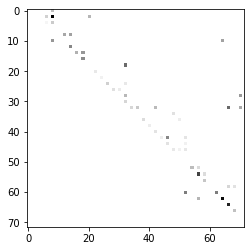

In [318]:
imshow(tl, interpolation='none', cmap='Greys')

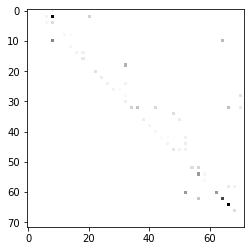

In [323]:
imshow(a_or, interpolation='none', cmap='Greys')

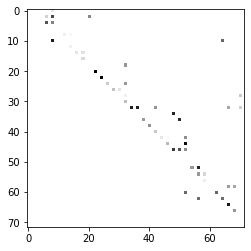

In [324]:
imshow(rho, interpolation='none', cmap='Greys')

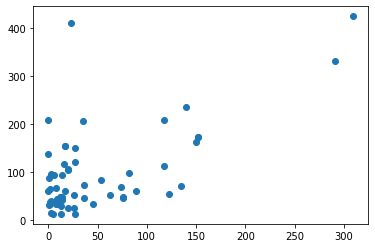

In [367]:
# Dependence of current on 1-hop disparity
x, y = [], []
for line_id in range(obs.n_line):
    st = obs.state_of(line_id=line_id)
    i = bus_id(st['origin']['sub_id'], st['origin']['bus'])
    j = bus_id(st['extremity']['sub_id'], st['extremity']['bus'])
    x.append(abs(imb[i] - imb[j]))
    y.append(st['origin']['a'])
scatter(x, y)

In [370]:
thermal_limit.argsort()

array([ 0, 34, 39, 13, 25, 35, 29, 16, 37, 32, 11, 20, 38, 36, 26, 31, 51,
       33, 15, 43, 24, 41, 22, 21, 50,  3, 14,  1, 23, 44, 52,  2, 40, 28,
       17, 27, 12, 57,  8, 54,  5, 46,  6, 53, 55,  9, 10,  7, 30, 45, 56,
       19, 18, 48, 49, 42, 58, 47,  4])

In [401]:
# Trafo are lines 55-58
obs.a_or[55:], thermal_limit[55:]

(array([236.47014, 208.77806, 138.41632, 425.32828], dtype=float32),
 array([370.5, 441. , 300.3, 656.2], dtype=float32))

(array([26., 12.,  7.,  7.,  3.,  1.,  0.,  1.,  0.,  2.]),
 array([ 12.611001,  53.88273 ,  95.15446 , 136.42618 , 177.6979  ,
        218.96964 , 260.24136 , 301.5131  , 342.78482 , 384.05655 ,
        425.32828 ], dtype=float32),
 <BarContainer object of 10 artists>)

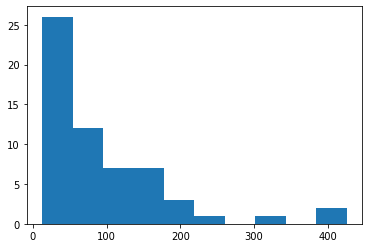

In [402]:
hist(obs.a_or)

(array([12., 13.,  6., 10.,  6.,  4.,  4.,  1.,  1.,  2.]),
 array([ 60.9    , 129.73   , 198.56   , 267.39   , 336.22   , 405.05002,
        473.88   , 542.71   , 611.54004, 680.37   , 749.2    ],
       dtype=float32),
 <BarContainer object of 10 artists>)

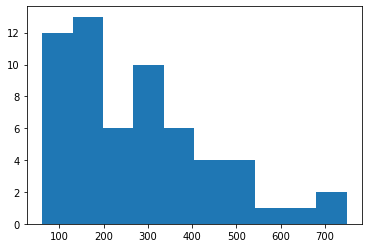

In [403]:
hist(thermal_limit)

In [406]:
thermal_limit.argsort()

array([ 0, 34, 39, 13, 25, 35, 29, 16, 37, 32, 11, 20, 38, 36, 26, 31, 51,
       33, 15, 43, 24, 41, 22, 21, 50,  3, 14,  1, 23, 44, 52,  2, 40, 28,
       17, 27, 12, 57,  8, 54,  5, 46,  6, 53, 55,  9, 10,  7, 30, 45, 56,
       19, 18, 48, 49, 42, 58, 47,  4])

In [398]:
env.backend.init_pp_backend._grid.trafo.columns

Index(['df', 'hv_bus', 'i0_percent', 'in_service', 'lv_bus',
       'max_loading_percent', 'name', 'parallel', 'pfe_kw', 'shift_degree',
       'sn_mva', 'std_type', 'tap_max', 'tap_neutral', 'tap_min',
       'tap_phase_shifter', 'tap_pos', 'tap_side', 'tap_step_degree',
       'tap_step_percent', 'vn_hv_kv', 'vn_lv_kv', 'vk_percent', 'vkr_percent',
       'old_hv_bus', 'old_lv_bus', 'old_name'],
      dtype='object')

In [395]:
env.backend.init_pp_backend._grid.trafo

,df,hv_bus,i0_percent,in_service,lv_bus,max_loading_percent,name,parallel,pfe_kw,shift_degree,...,tap_side,tap_step_degree,tap_step_percent,vn_hv_kv,vn_lv_kv,vk_percent,vkr_percent,old_hv_bus,old_lv_bus,old_name
0,1.0,5,0.0,True,4,100.0,37_36_179,1,0.0,0.0,...,hv,NaN,6.5,345.0,138.0,371.25,0.0,37,36,37_36_179
1,1.0,30,0.0,True,26,100.0,62_58_180,1,0.0,0.0,...,hv,NaN,4.0,345.0,138.0,382.14,0.0,62,58,62_58_180
2,1.0,31,0.0,True,28,100.0,63_60_181,1,0.0,0.0,...,hv,NaN,1.5,345.0,138.0,265.32,0.0,63,60,63_60_181
3,1.0,32,0.0,True,33,100.0,64_65_182,1,0.0,0.0,...,hv,NaN,6.5,345.0,138.0,366.30,0.0,64,65,64_65_182


In [394]:
env.backend.init_pp_backend._grid.line

,c_nf_per_km,df,from_bus,g_us_per_km,in_service,length_km,max_i_ka,max_loading_percent,name,parallel,r_ohm_per_km,std_type,to_bus,type,x_ohm_per_km,old_from_bus,old_to_bus,old_name
0,37.328927,1.0,2,0.0,True,1.0,99999,100.0,34_35_110,1,0.426586,None,3,ol,1.942488,34,35,34_35_110
1,183.580318,1.0,2,0.0,True,1.0,99999,100.0,34_36_111,1,2.094840,None,4,ol,9.464868,34,36,34_36_111
2,509.790565,1.0,0,0.0,True,1.0,99999,100.0,32_36_112,1,7.903260,None,4,ol,27.042480,32,36,32_36_112
3,79.115039,1.0,1,0.0,True,1.0,99999,100.0,33_35_113,1,1.658732,None,3,ol,5.103792,33,35,33_35_113
4,137.058447,1.0,1,0.0,True,1.0,99999,100.0,33_36_114,1,0.487526,None,4,ol,1.790136,33,36,33_36_114
5,376.075007,1.0,4,0.0,True,1.0,99999,100.0,36_38_115,1,6.113124,None,6,ol,20.186640,36,38,36_38_115
6,585.005567,1.0,4,0.0,True,1.0,99999,100.0,36_39_116,1,11.293092,None,7,ol,31.993920,36,39,36_39_116
7,216.173486,1.0,6,0.0,True,1.0,99999,100.0,38_39_119,1,3.504096,None,7,ol,11.521620,38,39,38_39_119
8,170.208763,1.0,7,0.0,True,1.0,99999,100.0,39_40_120,1,2.761380,None,8,ol,9.274428,39,40,39_40_120
9,649.077605,1.0,7,0.0,True,1.0,99999,100.0,39_41_121,1,10.569420,None,9,ol,34.850520,39,41,39_41_121


In [371]:
obs.a_or.argmax(), obs.rho.argmax()

(58, 11)

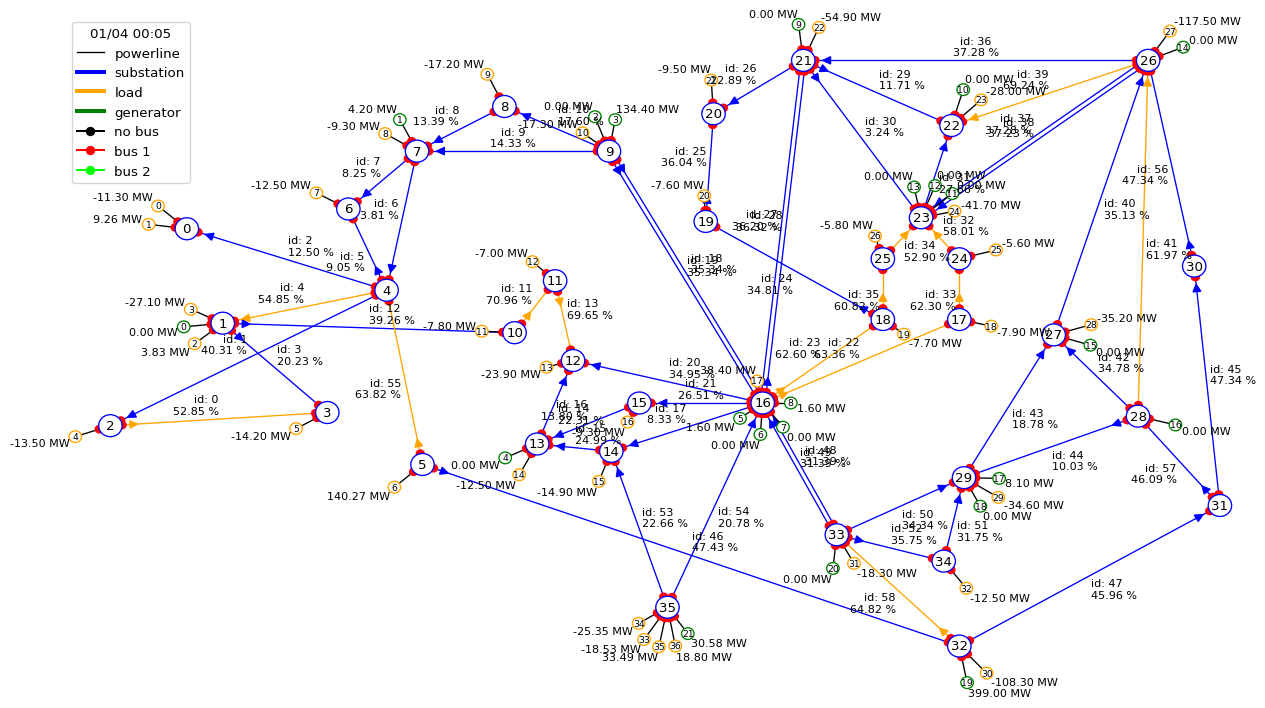

In [373]:
_ = plot_helper.plot_obs(obs)

In [410]:
obss[-1].time_before_cooldown_line

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0, 10,  7,  0,  0,  0, 39,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0], dtype=int32)

In [412]:
obss[-1].rho[34]

2.3347957

In [413]:
obss[-2].rho[34]

2.3347957

In [414]:
obss[-3].rho[34]

2.315107

In [415]:
obss[-4].rho[34]

2.2681684

In [416]:
env.parameters.HARD_OVERFLOW_THRESHOLD

200.0

In [417]:
env.hard_overflow_threshold

200.0

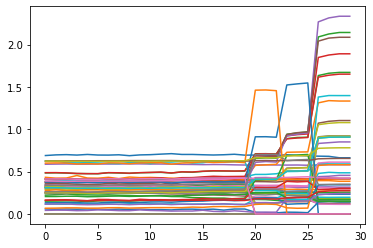

In [421]:
plot([ob.rho for ob in obss[-30:]])

In [431]:
obss[-10].rho.argmax()

41

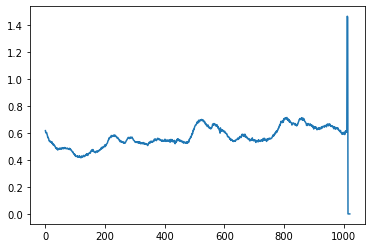

In [434]:
plot([ob.rho[41] for ob in obss])

In [435]:
[ob.rho[41] == 0 for ob in obss].index(True)

1015

In [442]:
obss[1011].rho[41], obss[1012].rho[41], obss[1013].rho[41], obss[1014].rho[41], obss[1015].rho[41]

(0.60503453, 1.46171, 1.4640272, 1.4556415, 0.0)

In [447]:
obss[1014].time_before_cooldown_line[41], obss[1015].time_before_cooldown_line[41], obss[1016].time_before_cooldown_line[41]

(0, 12, 11)

In [450]:
(env.chronics_handler.data.prod_p[1:] - env.chronics_handler.data.prod_p[:-1]).max(0)

array([1.3      , 1.3999996, 1.3      , 5.100006 , 0.       , 1.2999992,
       1.       , 1.       , 1.1999989, 1.8000011, 2.7      , 0.8999996,
       1.       , 2.7      , 1.8999996, 1.7999992, 3.9      , 1.       ,
       1.8999977, 2.7000122, 0.       , 5.5      ], dtype=float32)

In [451]:
env.gen_max_ramp_up

array([ 1.4,  0. ,  1.4, 10.4,  1.4,  0. ,  0. ,  0. ,  0. ,  0. ,  2.8,
        0. ,  0. ,  2.8,  0. ,  0. ,  4.3,  0. ,  0. ,  2.8,  8.5,  9.9],
      dtype=float32)

In [460]:
env.gen_redispatchable * _450 <= _451

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True])

In [474]:
env.chronics_handler.data.name_line

array(['34_35_110', '34_36_111', '32_36_112', '33_35_113', '33_36_114',
       '36_38_115', '36_39_116', '38_39_119', '39_40_120', '39_41_121',
       '40_41_122', '42_43_123', '33_42_124', '43_44_125', '44_45_126',
       '45_46_127', '45_47_128', '46_48_130', '41_48_131', '41_48_132',
       '44_48_133', '47_48_134', '48_49_135', '48_50_136', '50_51_137',
       '51_52_138', '52_53_139', '48_53_141', '48_53_142', '53_54_143',
       '53_55_144', '54_55_145', '55_56_146', '49_56_147', '55_57_148',
       '50_57_149', '53_58_150', '55_58_152', '55_58_153', '54_58_154',
       '58_59_155', '58_60_156', '59_60_157', '59_61_158', '60_61_159',
       '62_63_160', '37_64_161', '63_64_163', '48_65_164', '48_65_165',
       '61_65_166', '61_66_167', '65_66_168', '46_68_169', '48_68_170',
       '37_36_179', '62_58_180', '63_60_181', '64_65_182'], dtype='<U9')

In [463]:
env.chronics_handler.data.line_to_maintenance

{'34_35_110',
 '39_41_121',
 '41_48_131',
 '43_44_125',
 '44_45_126',
 '48_50_136',
 '48_53_141',
 '54_58_154',
 '62_58_180',
 '62_63_160'}

In [473]:
env.opponent._lines_ids

[56, 45, 23, 27, 18, 9, 13, 14, 0, 39]

In [480]:
[argwhere(env.chronics_handler.data.name_line == l)[0, 0] for l in env.chronics_handler.data.line_to_maintenance]

[39, 18, 27, 56, 9, 13, 45, 0, 14, 23]

In [482]:
sorted(_480)

[0, 9, 13, 14, 18, 23, 27, 39, 45, 56]

In [490]:
obs.state_of(line_id=56)

{'origin': {'p': 117.65208,
  'q': 56.64104,
  'v': 361.09335,
  'a': 208.77806,
  'bus': 1,
  'sub_id': 30},
 'extremity': {'p': -117.65208,
  'q': -51.10424,
  'v': 147.8,
  'a': 501.06735,
  'bus': 1,
  'sub_id': 26},
 'maintenance': {'next': -1, 'duration_next': 0},
 'cooldown_time': 0}

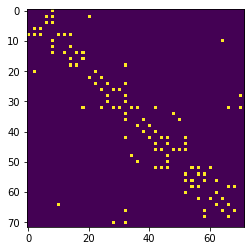

In [503]:
# Connectivity analysis
# Degrees
adj = (tl > 0) + (tl.T > 0)
imshow(adj)

<BarContainer object of 72 artists>

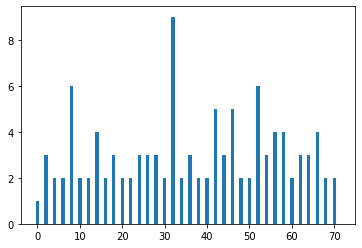

In [507]:
bar(range(72), adj.sum(1))

(array([36.,  1., 16., 10.,  4.,  2.,  2.,  0.,  0.,  1.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

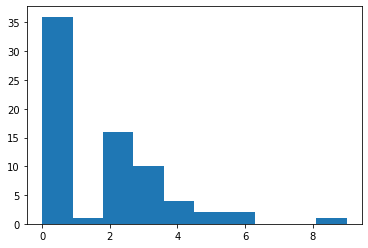

In [506]:
hist(adj.sum(1))

In [511]:
where(env.gen_redispatchable)

(array([ 0,  2,  3,  4, 10, 13, 16, 19, 20, 21]),)